# Tests for Means, Variances and Proportions- Two Samples

## Two Samples Z Test:

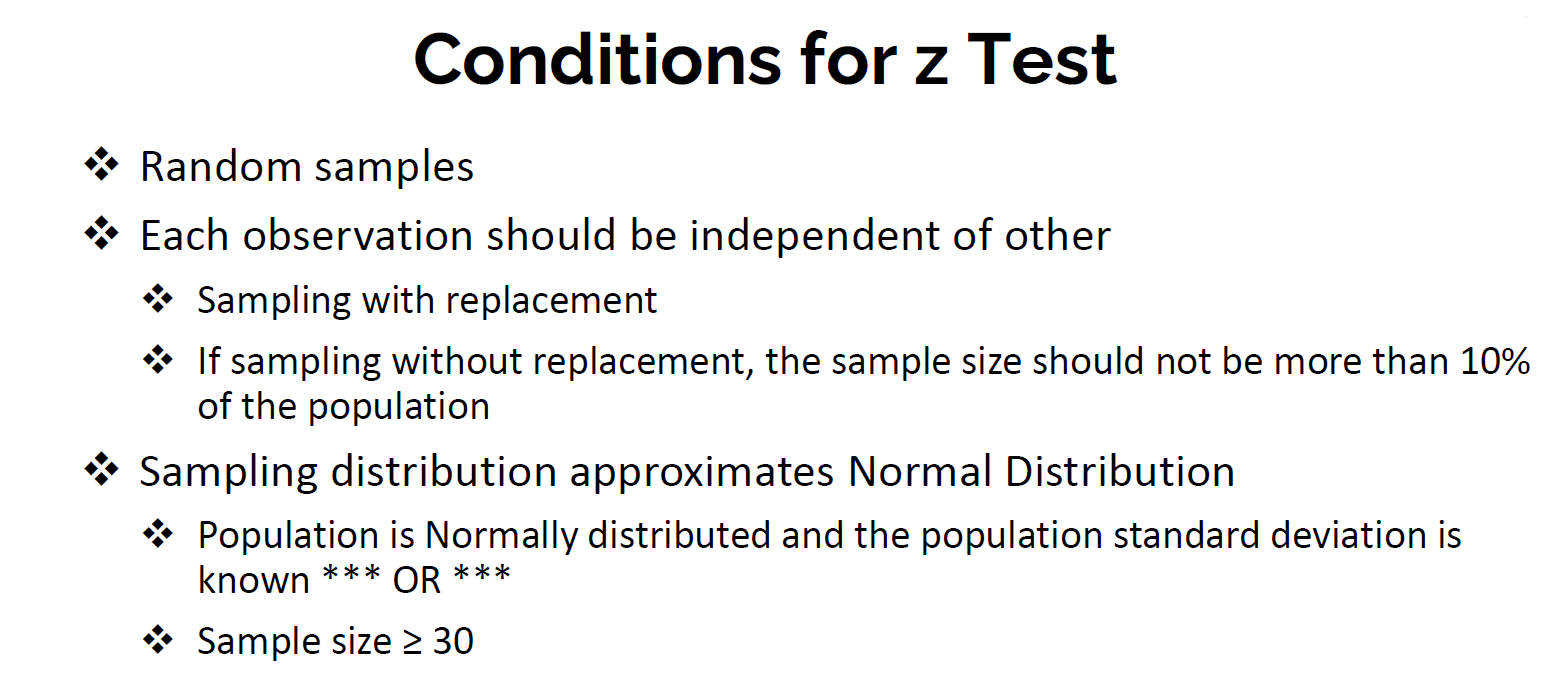

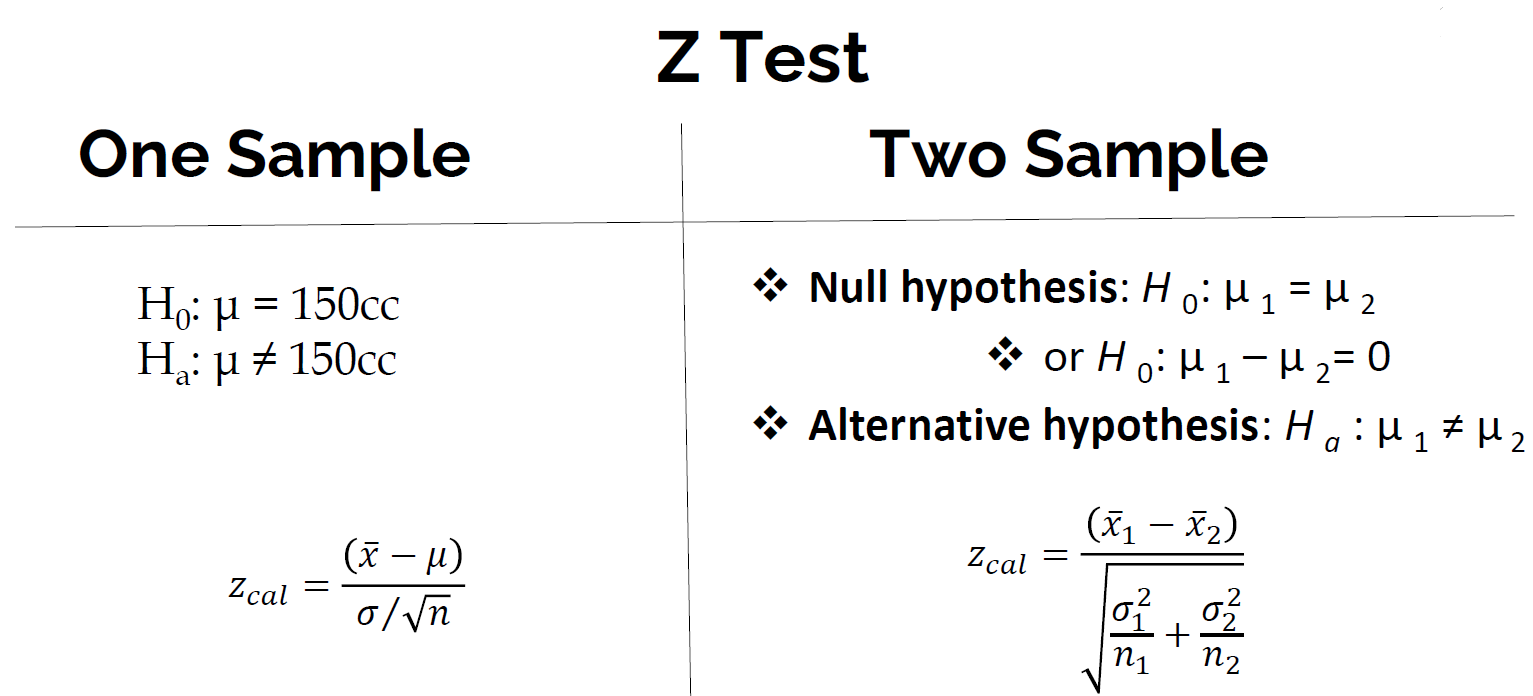

### Example:

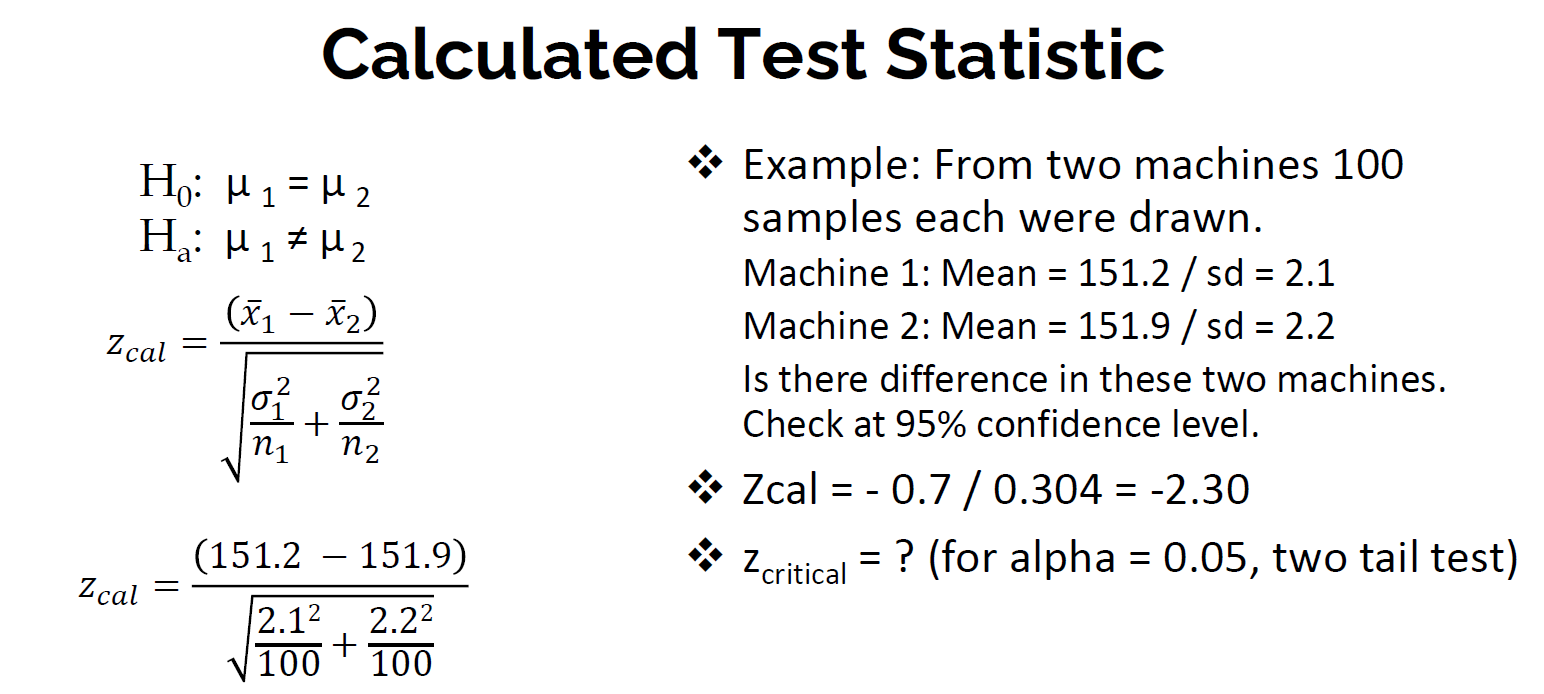

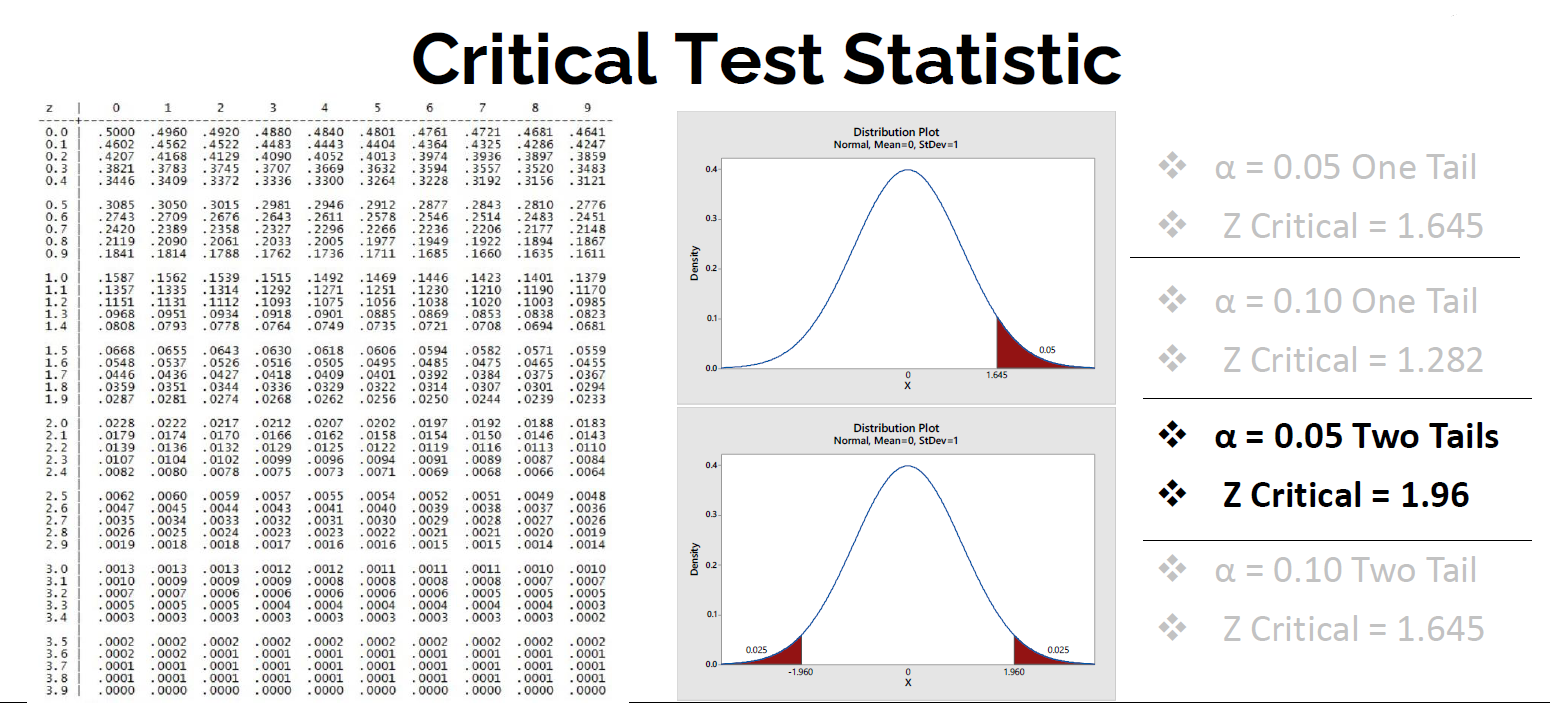

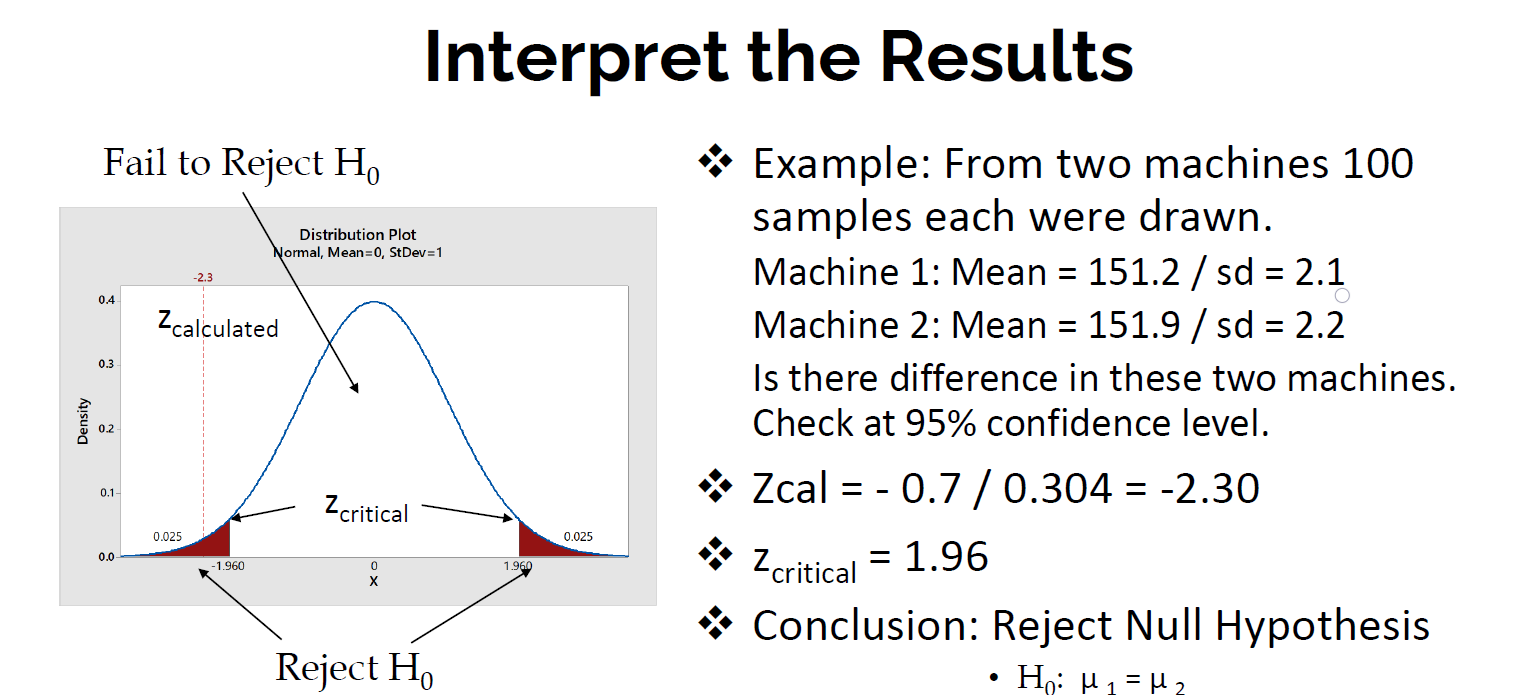

### Two Sample Z Test Using Python:

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats import weightstats # For 2 Sample z-Test.
from scipy.stats import ttest_ind # For 2 Independent Sample t-Test.

from scipy.stats import ttest_rel ## For 2 Dependent / Related Sample t-Test.

from statsmodels.stats.proportion import test_proportions_2indep # For 2 Proportion Test.

from scipy.stats import f, bartlett, levene # For 2 Sample Variance Test.

##### Example 1: From two machines 100 samples each were drawn.

##### Machine 1: Mean = 151.2 and sd = 2.1

#### Machine 2: Mean = 151.9 and sd = 2.2

##### Is there difference in these two machines. Check at 95% confidence level.

H0 : μ1 = μ2

Ha : μ1 != μ2

alpha = 0.05

In [2]:
df = pd.read_csv('Two Machines.csv')

In [3]:
df.head()

,Volume,Machine
0,154.27,Machine 1
1,150.03,Machine 1
2,151.14,Machine 1
3,145.47,Machine 1
4,149.71,Machine 1


In [4]:
df.shape

(200, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Volume   200 non-null    float64
 1   Machine  200 non-null    object 
dtypes: float64(1), object(1)
memory usage: 3.3+ KB


In [6]:
df.describe()

,Volume
count,200.000000
mean,151.538350
std,2.180823
min,145.440000
25%,150.015000
50%,151.515000
75%,153.110000
max,156.230000


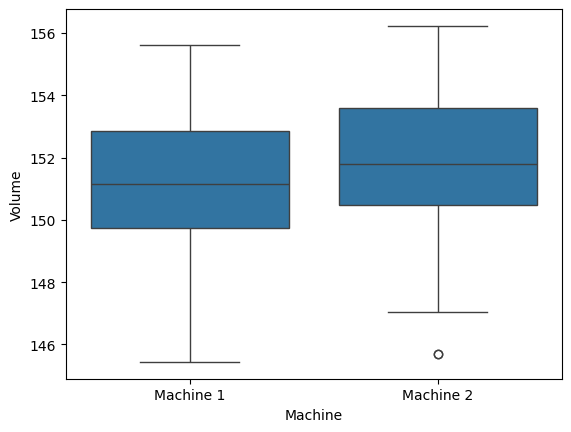

In [7]:
# Plotting:

sns.boxplot(data = df, x= 'Machine', y= 'Volume')
plt.show()

In [10]:
# Separating Data for Both Machines in Different Dataframes:
machine1 = df[df['Machine'] == 'Machine 1']['Volume']
machine2 = df[df['Machine'] == 'Machine 2']['Volume']

In [11]:
machine1.head()

0    154.27
1    150.03
2    151.14
3    145.47
4    149.71
Name: Volume, dtype: float64

In [12]:
machine2.head()

100    152.87
101    154.68
102    154.21
103    155.91
104    152.63
Name: Volume, dtype: float64

In [13]:
# Calculated Statisitcs:

z_calculated, p_value = weightstats.ztest(x1= machine1, x2= machine2, value= 0, alternative= 'two-sided')

In [14]:
print(z_calculated)
print(p_value)

-2.189406040190184
0.028567341032618248


alpha = 0.05

p_value = 0.028 < alpha.

**We Can Reject The Null Hypothesis.**

##### Example 2:

In Seaborn Library, there is a Dataset named Tips.

It contains details about bill amount, tip, time of meal, gender of person paying the bill etc.

Find out if There's a Significant Difference Between Tip paid by male and Female.

Fine out if There's a Significant Difference Between Tip paid at Lunch time and Dinner Time.

Use 95% Confidence Interval.

In [15]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [16]:
tips = sns.load_dataset('tips')

In [18]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [19]:
tips.shape

(244, 7)

In [20]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [21]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


##### Case 1:

H0 : μm = μf

Ha : μm != μf

alpha = 0.05

In [24]:
# Separating Data For Genders in Differenr Dataframes:

male_tips = tips[tips['sex'] == 'Male']['tip']
female_tips = tips[tips['sex'] == 'Female']['tip']

In [25]:
male_tips.head()

1    1.66
2    3.50
3    3.31
5    4.71
6    2.00
Name: tip, dtype: float64

In [26]:
female_tips.head()

0     1.01
4     3.61
11    5.00
14    3.02
16    1.67
Name: tip, dtype: float64

In [27]:
# Two Sample z-Test:

z_calculated, p_value = weightstats.ztest(x1= male_tips, x2= female_tips, value= 0, alternative= 'two-sided')

In [28]:
print(z_calculated)
print(p_value)

1.3878597054212687
0.1651797698624794


alpha = 0.05

p_value = 0.165 < alpha

**We can Reject The Null Hypothesis.**

##### Case 2:

H0 : μl = μd

Ha : μl != μd

alpha = 0.05

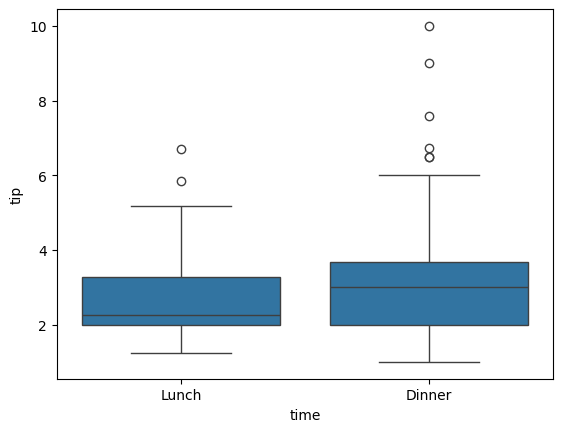

In [29]:
# Plotting Tips By Meal Time:

sns.boxplot(data= tips, x= 'time', y= 'tip')
plt.show()

In [30]:
# Separating Data for Lunch and Dinner in Different Dataframes:

lunch_tips = tips[tips['time'] == 'Lunch']['tip']
dinner_tips = tips[tips['time'] == 'Dinner']['tip']

In [31]:
lunch_tips.head()

77    4.00
78    3.00
79    2.71
80    3.00
81    3.40
Name: tip, dtype: float64

In [32]:
dinner_tips.head()

0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64

In [33]:
# Two Sample z-Test:

z_calculated, p_value = weightstats.ztest(x1= lunch_tips, x2= dinner_tips, value= 0, alternative= 'two-sided')

In [34]:
print(z_calculated)
print(p_value)

-1.9062569301202392
0.05661687925222567


alpha = 0.05

p_value = 0.056 > alpha

**We Can Not Reject Null Hypothesis.**

# -------------------------------------------------------------------------------------------------------------

## Two Sample t Test:

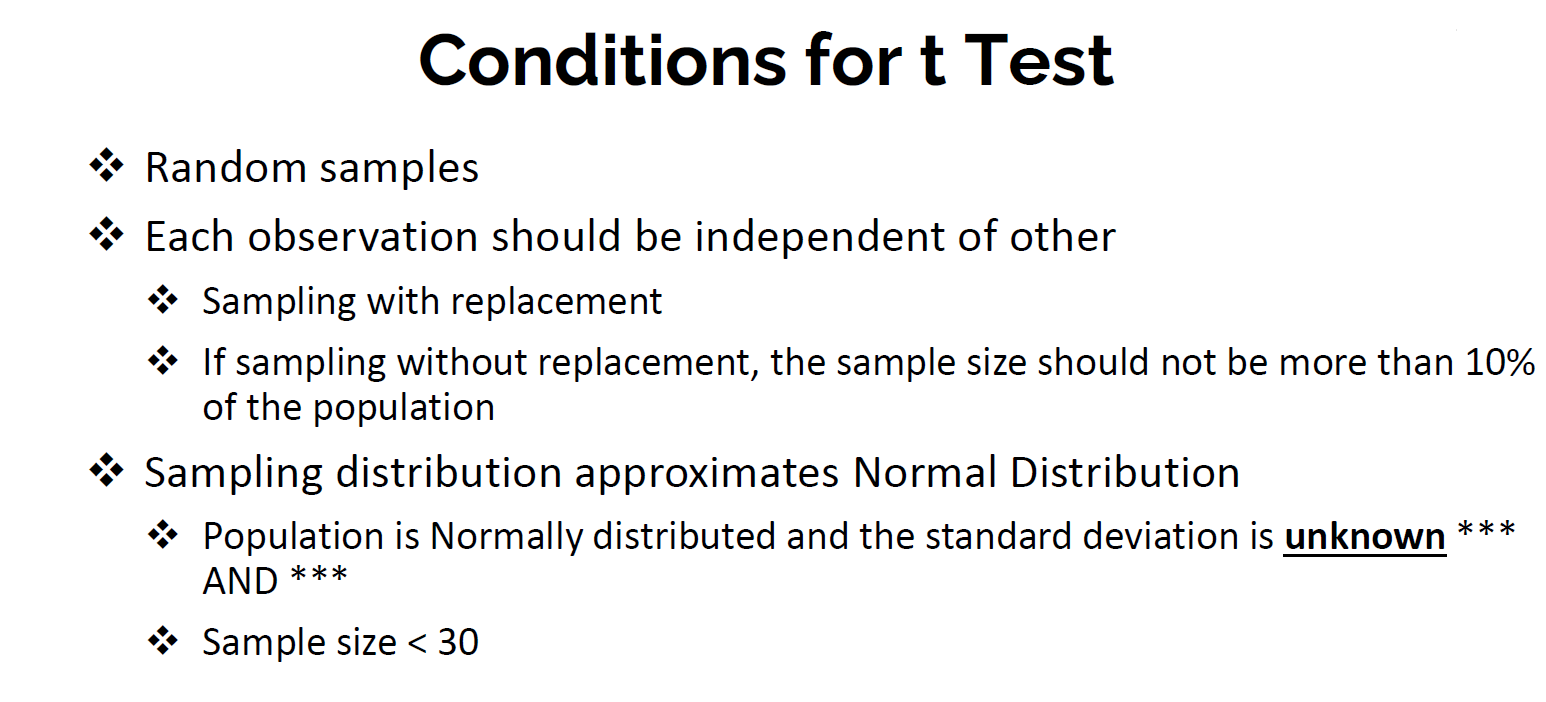

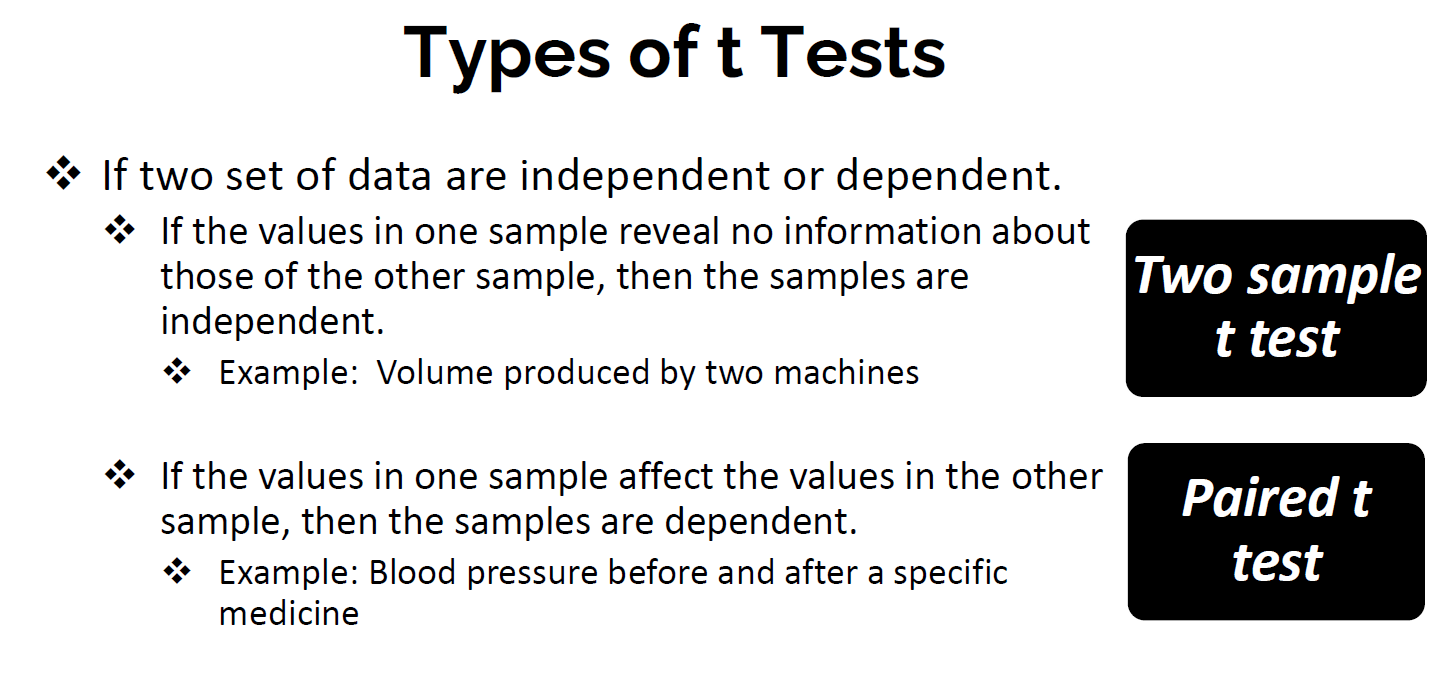

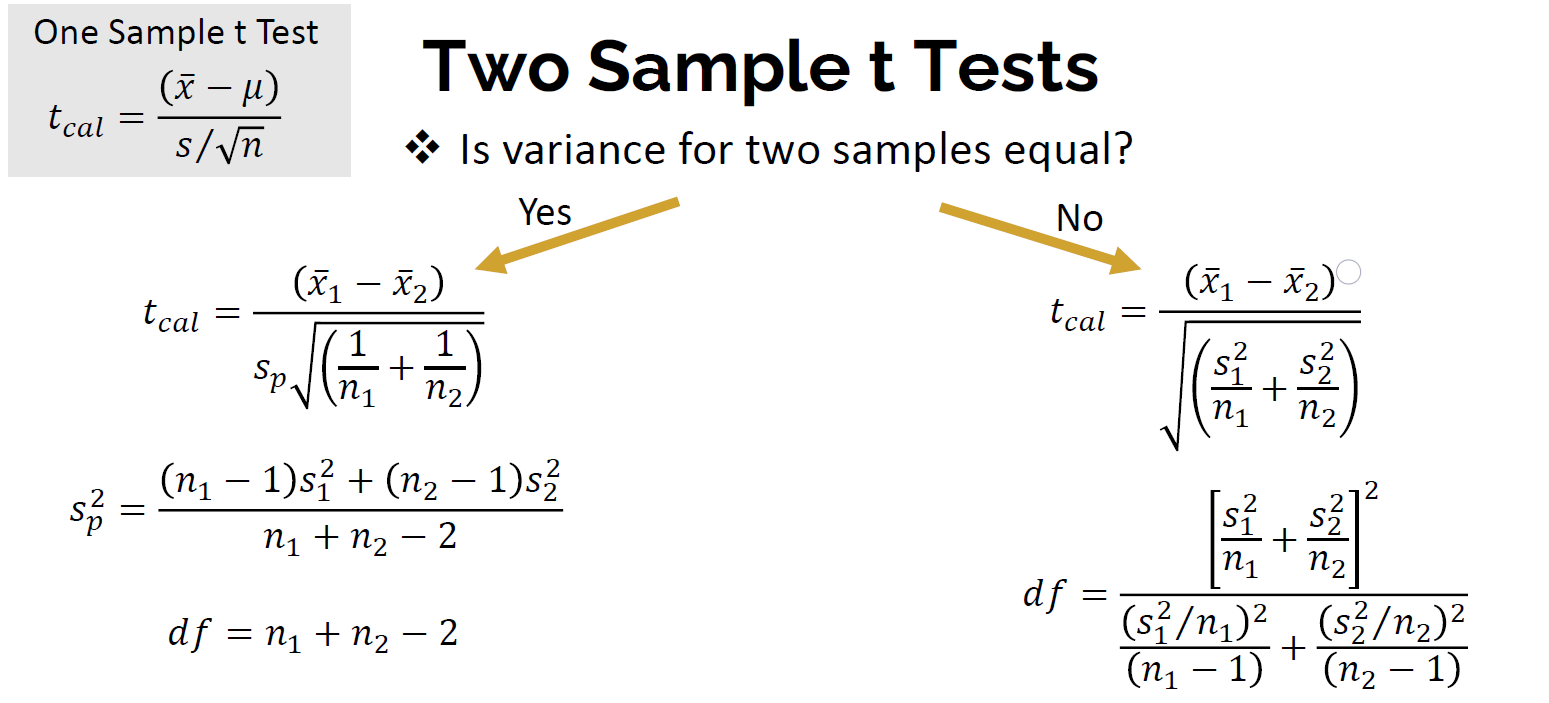

### Example 1 (Equal Variance):

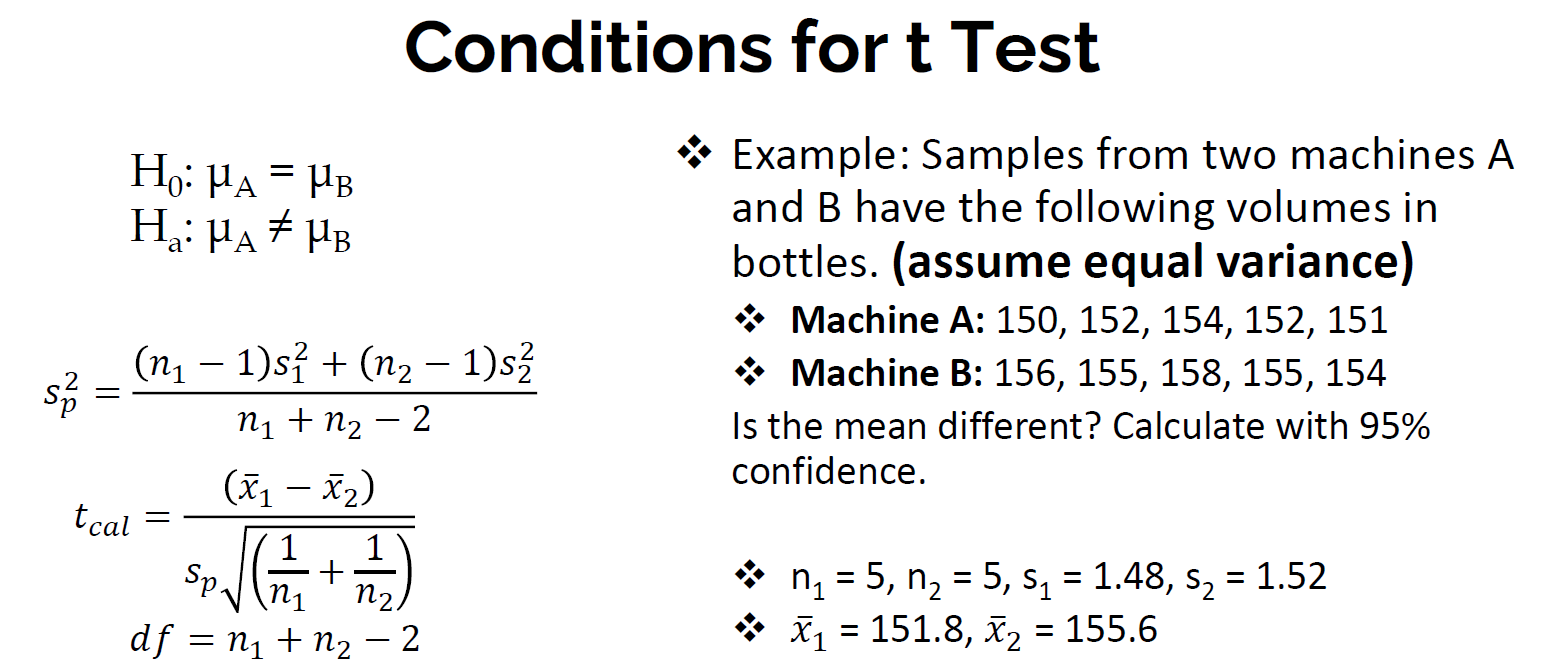

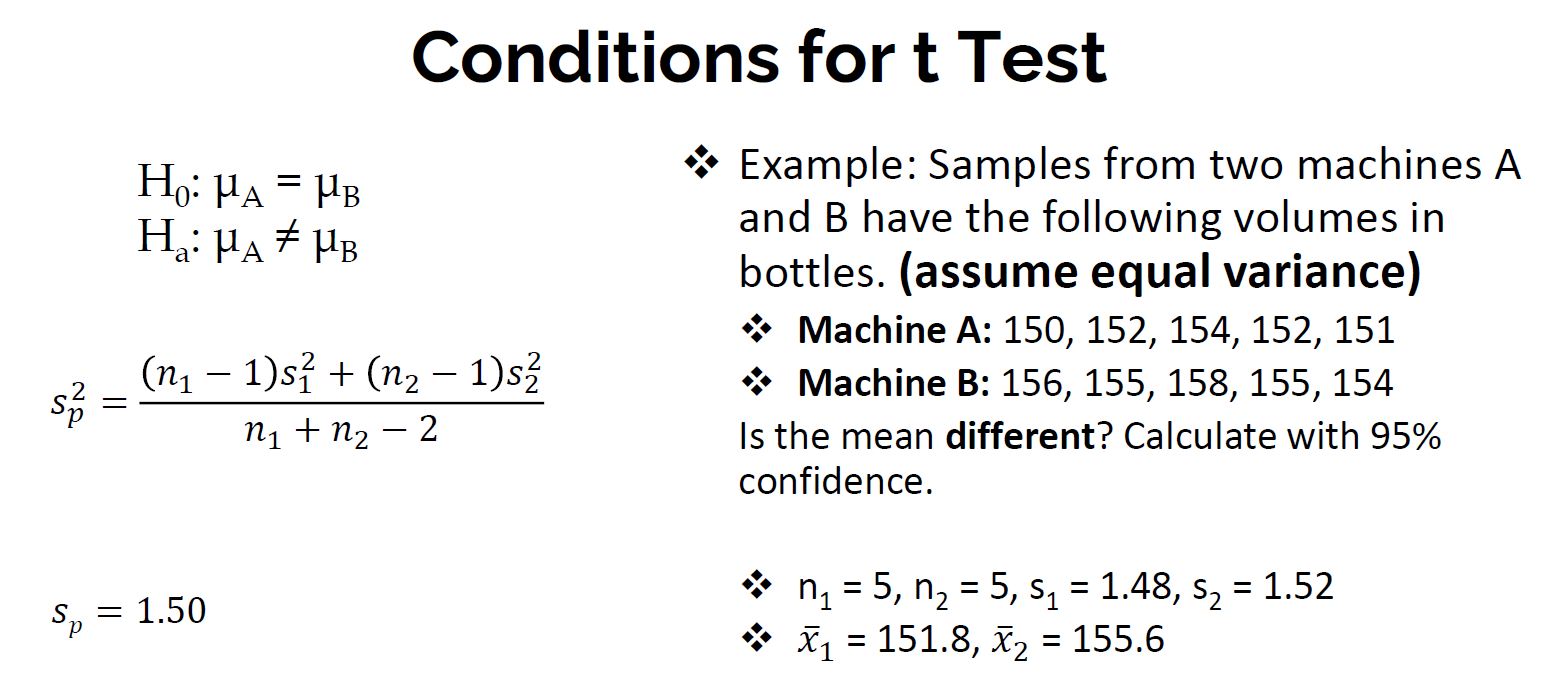

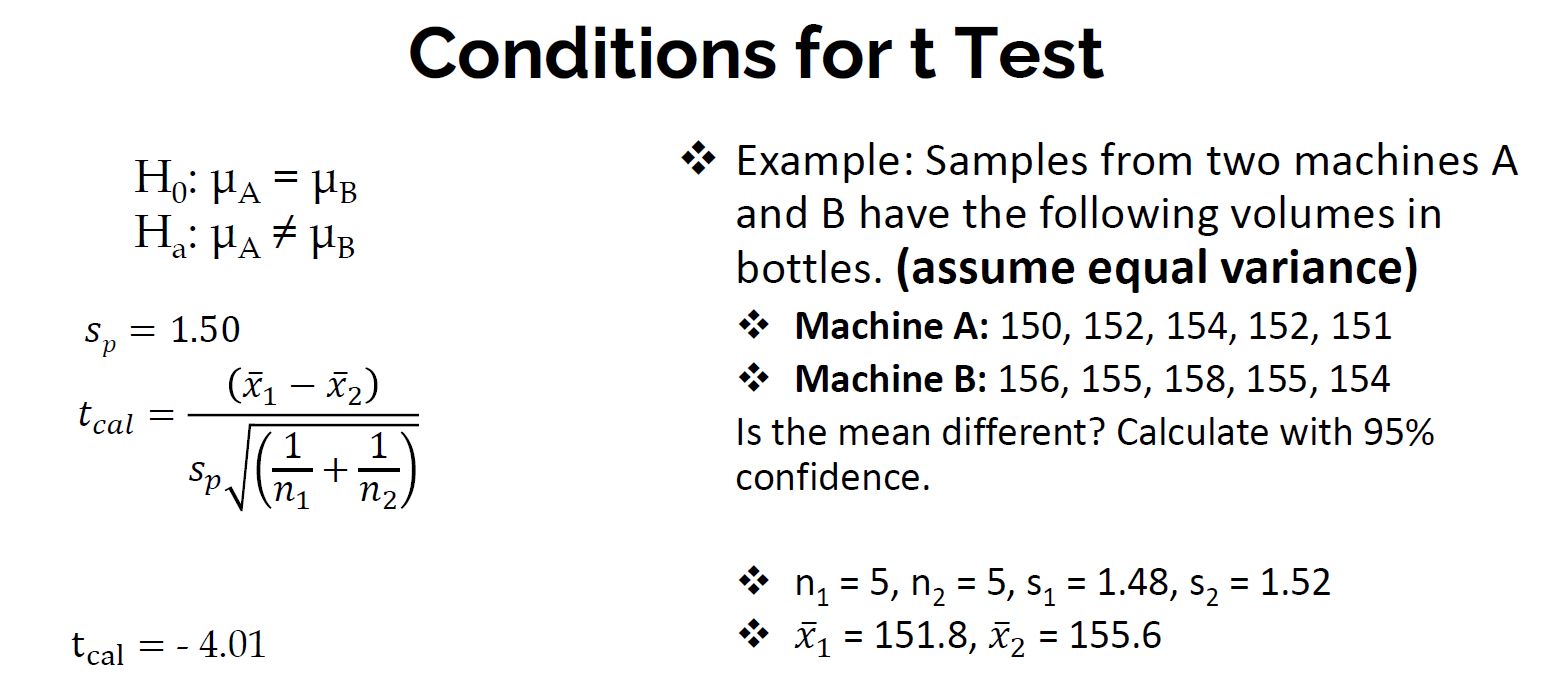

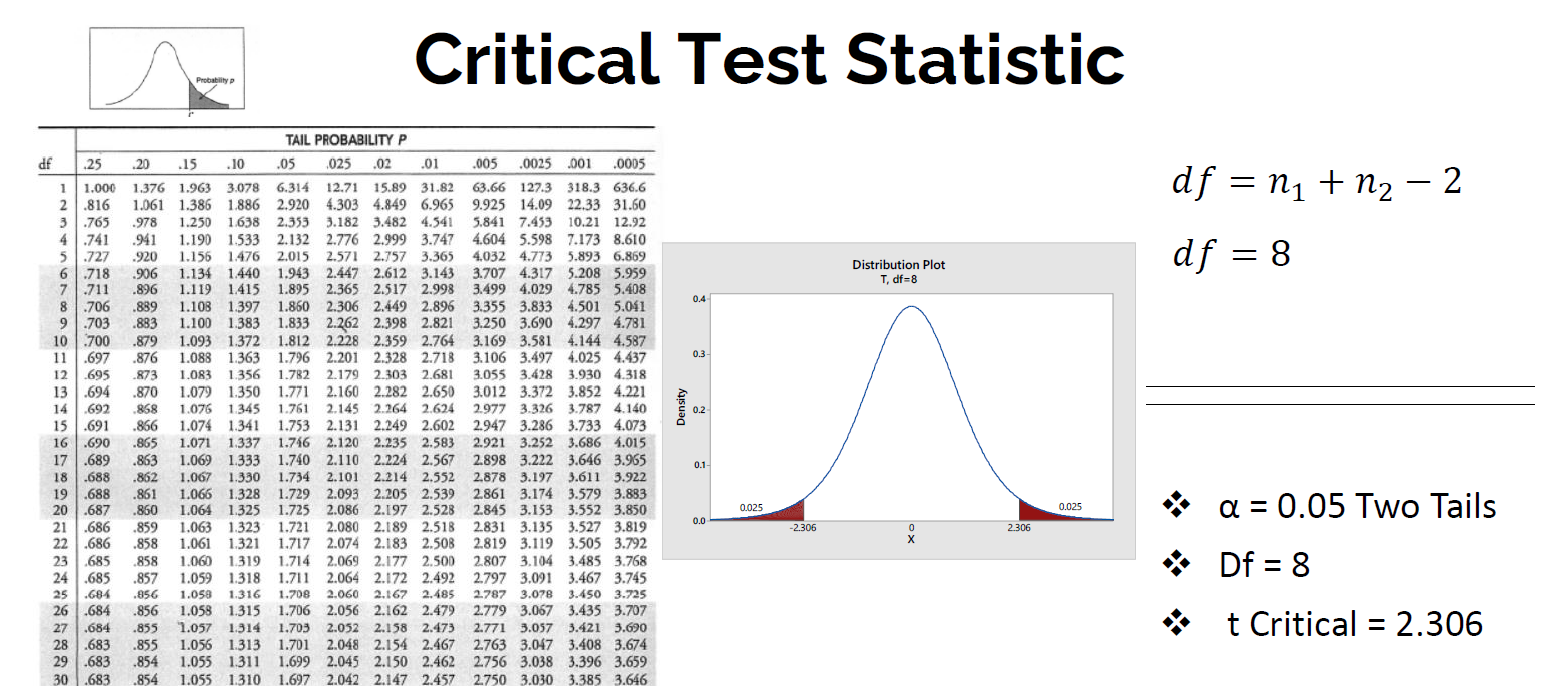

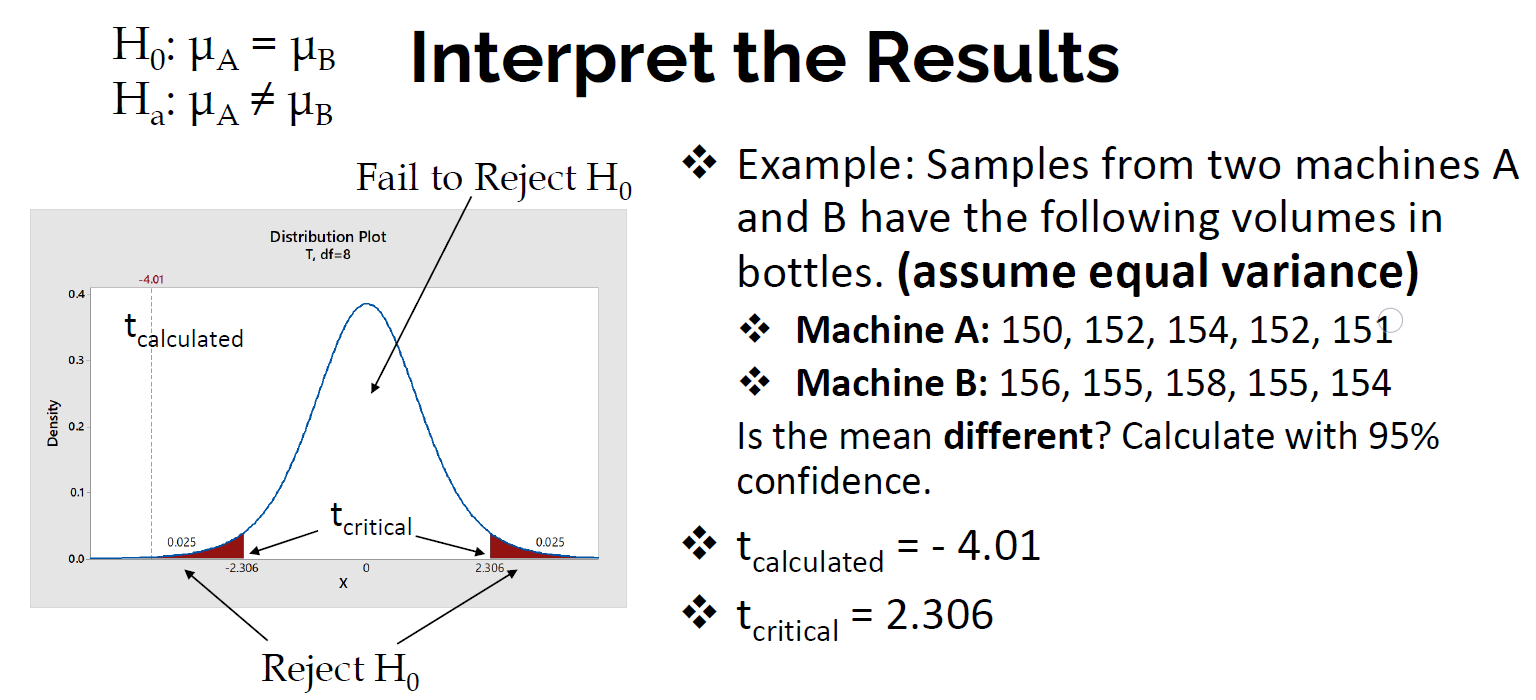

### Example 2 (Unequal Variance):

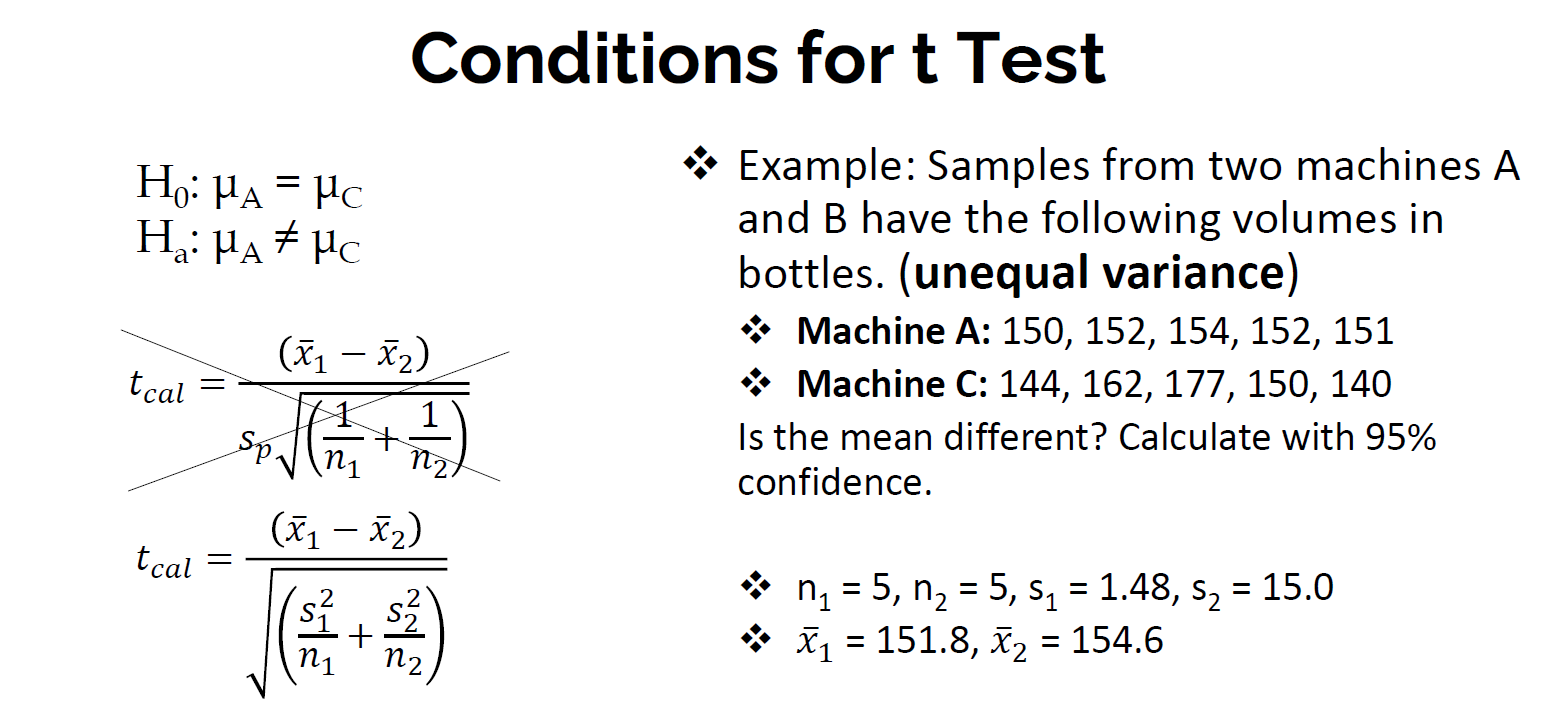

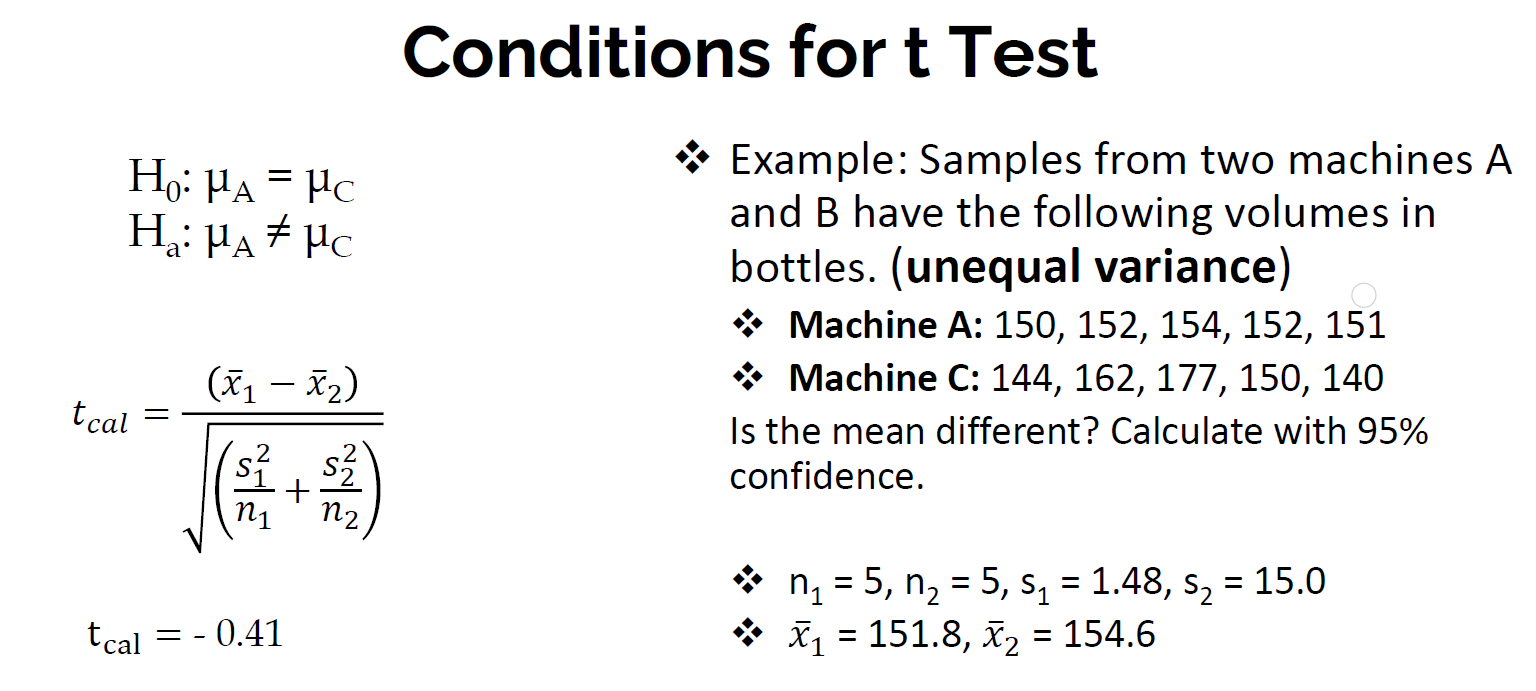

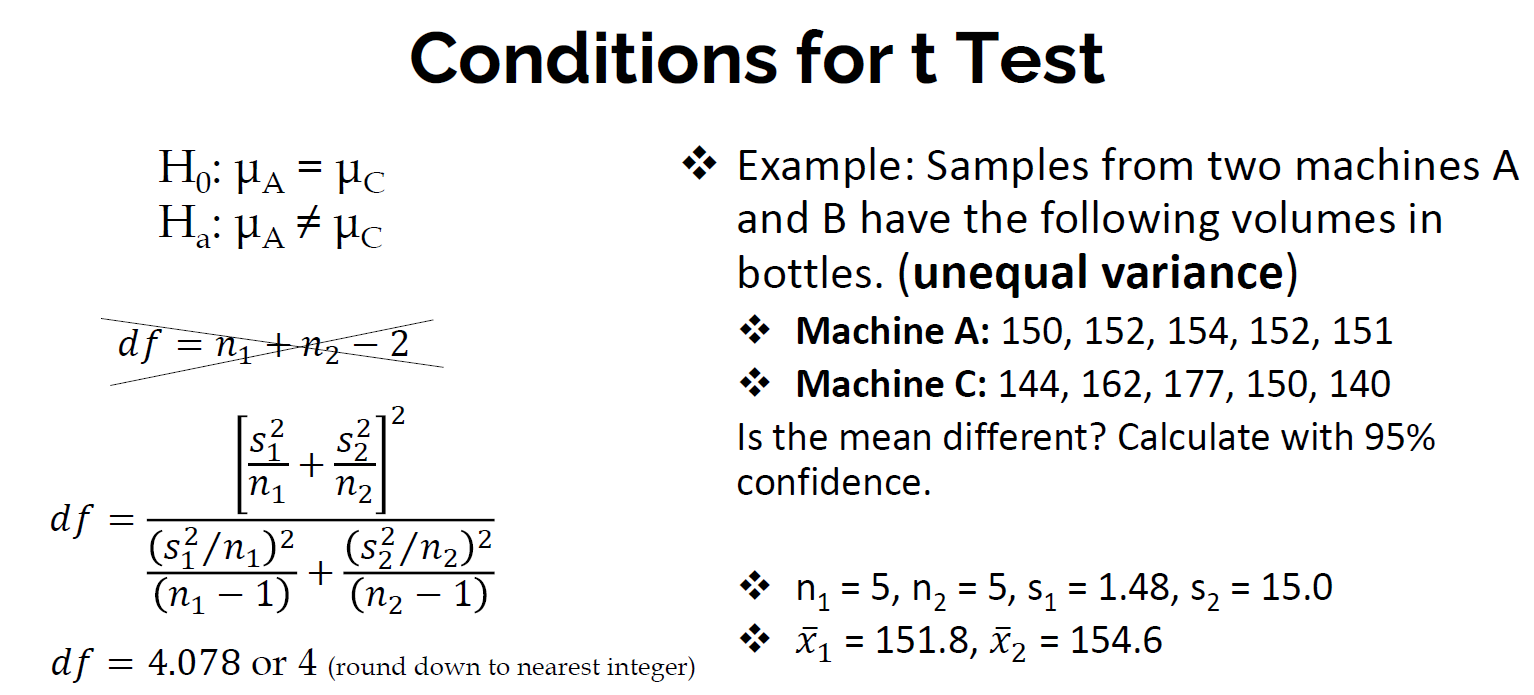

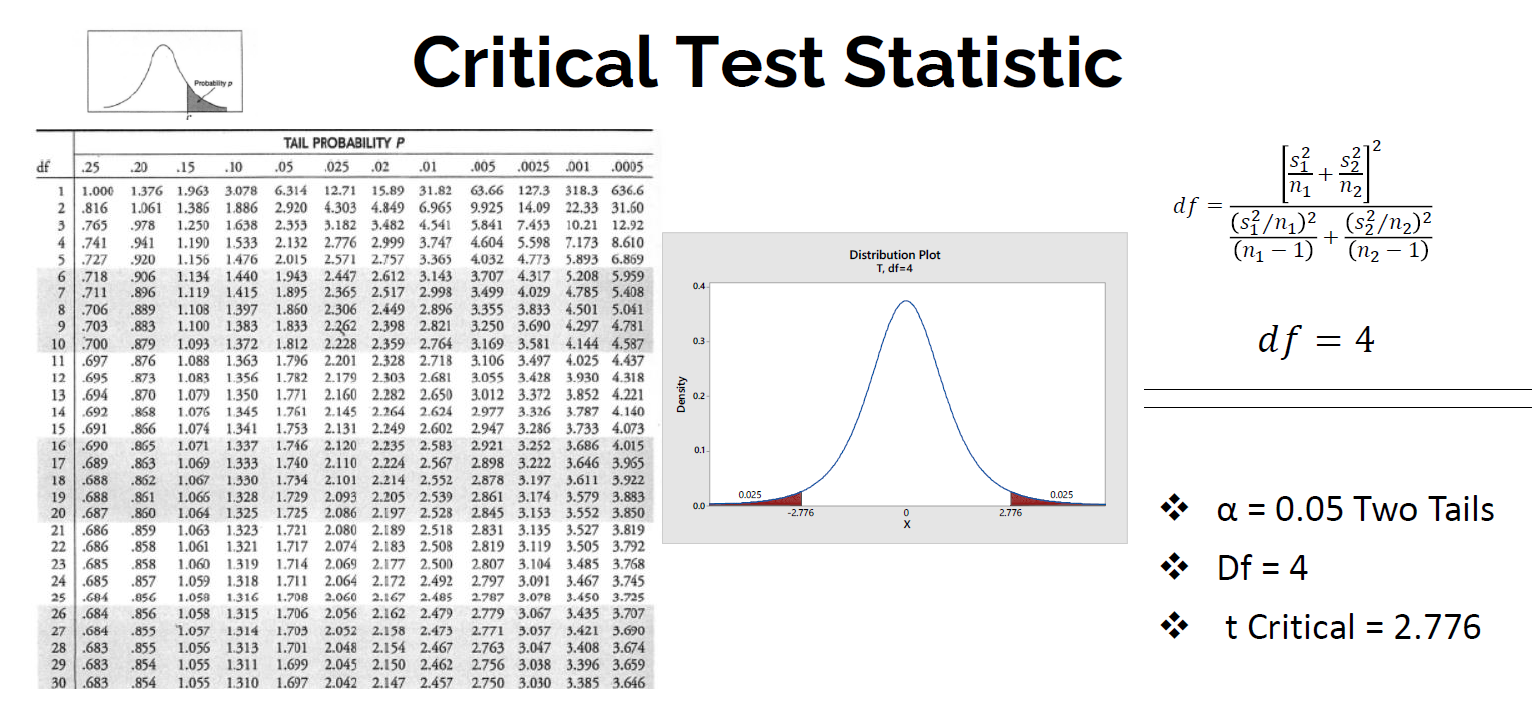

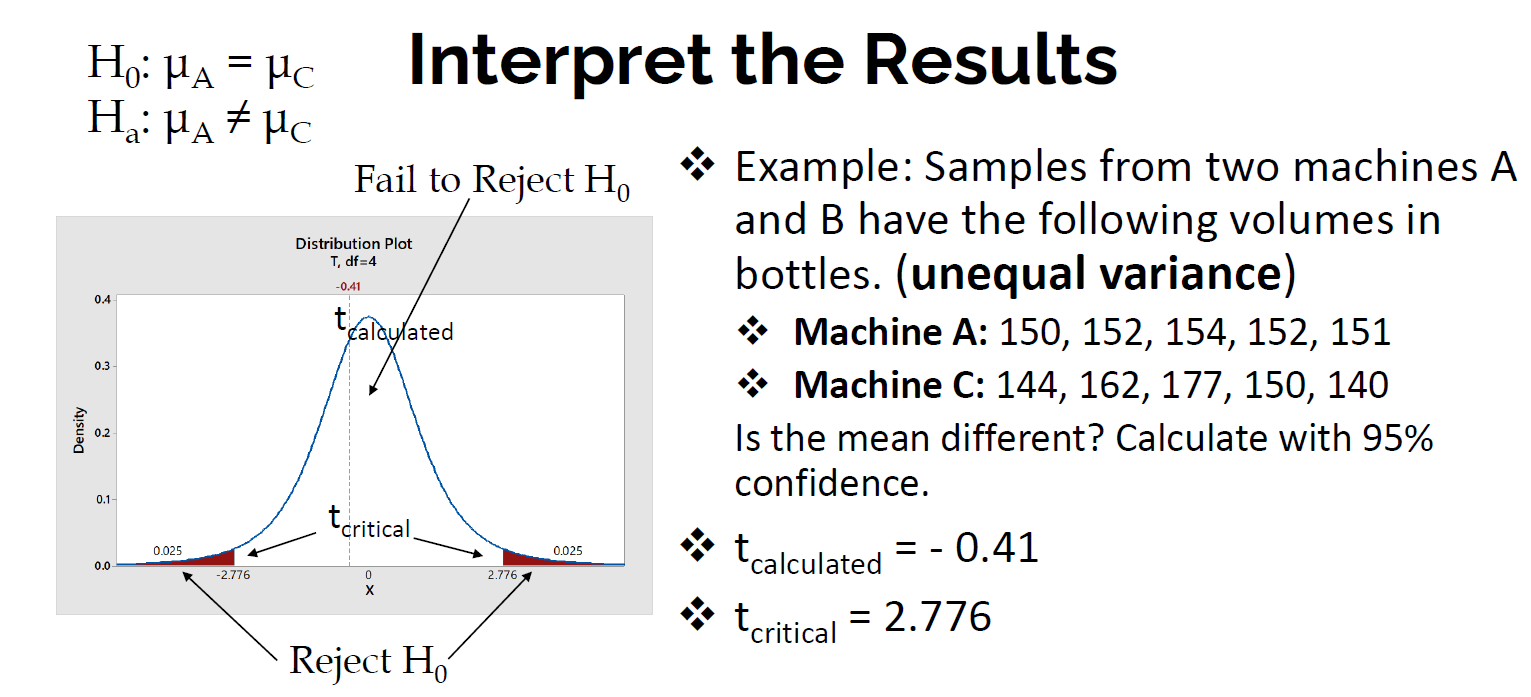

### Two Sample t Test Using Python:

##### Example 1 : Samples from two machines A and B have the following volumes in bottles. (assume equal Variance)

##### Machine A: 150, 152, 154, 152, 151

##### Machine B: 156, 155, 158, 155, 154

##### Is the mean different? Calculate with 95% confidence.

H0 : μA = μB

Ha : μA != μB

alpha = 0.05

In [36]:
m1= [150, 152, 154, 152, 151]
m2 = [156, 155, 158, 155, 154]

In [38]:
# Calculated Statistics:

t_calculated, p_value = ttest_ind(a= m1, b= m2, 
                                  equal_var= True, 
                                  alternative= 'two-sided')

In [39]:
print(t_calculated)
print(p_value)

-4.005551702879929
0.003919295477128331


alpha= 0.05

p_value = 0.004 < alpha

**We Can Reject The Null Hypothesis.**

##### Example: Samples from two machines A and C have the following volumes in bottles. (unequal variance)

##### Machine A: 150, 152, 154, 152, 151

##### Machine C: 144, 162, 177, 150, 140

##### Is the mean different? Calculate with 95% confidence.

H0 : μA = μC

Ha : μA != μC

alpha = 0.05

In [40]:
m1 = [150, 152, 154, 152, 151]
m2 = [144, 162, 177, 150, 140]

In [41]:
# Calculated Statistics:

t_calculated, p_value= ttest_ind(a= m1, b= m2,
                                equal_var= False,
                                alternative= 'two-sided')

In [42]:
print(t_calculated)
print(p_value)

-0.4146442144313621
0.699289145758865


alpha = 0.05

p_value = 0.69 > alpha

**We Can Not Reject The Null Hypothesis.**

# ----------------------------------------------------------------------------------------------------------

## Paired t Test:

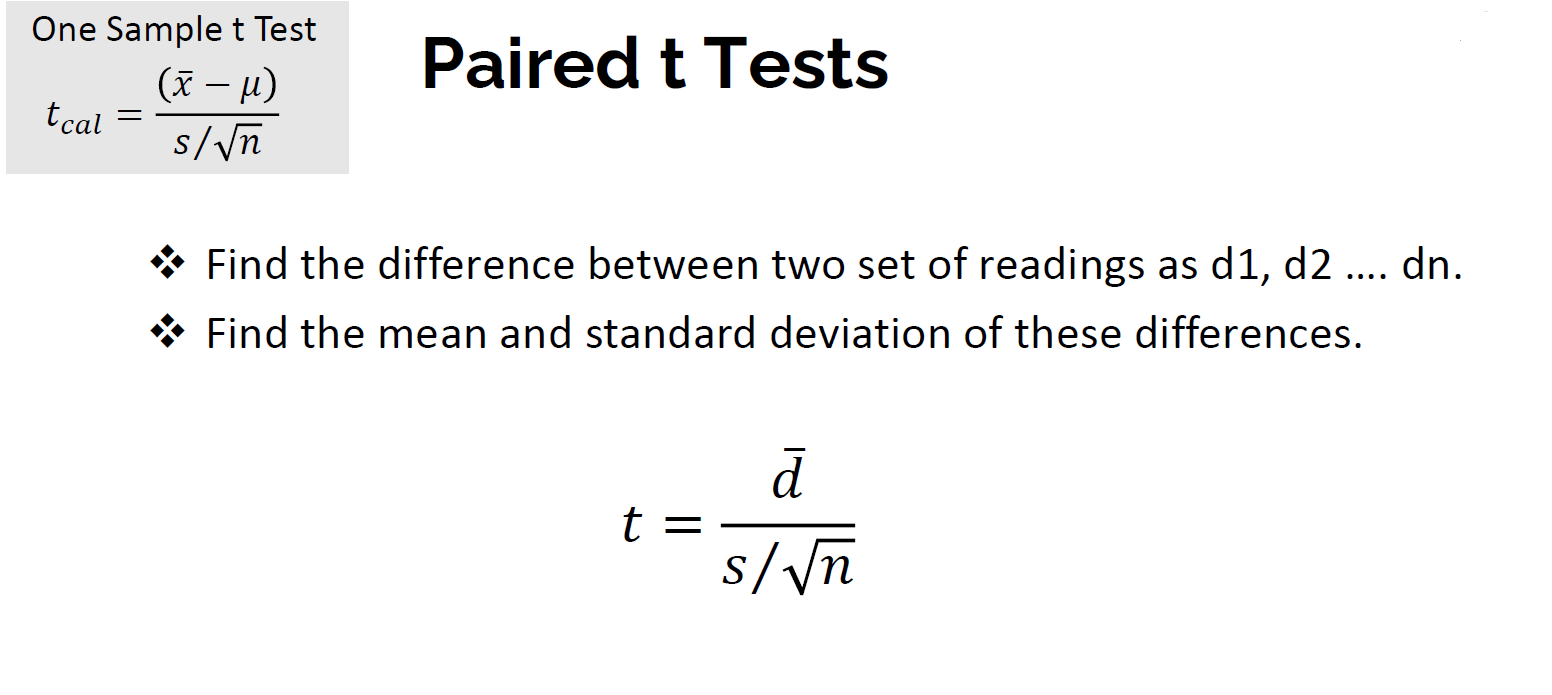

### Example :

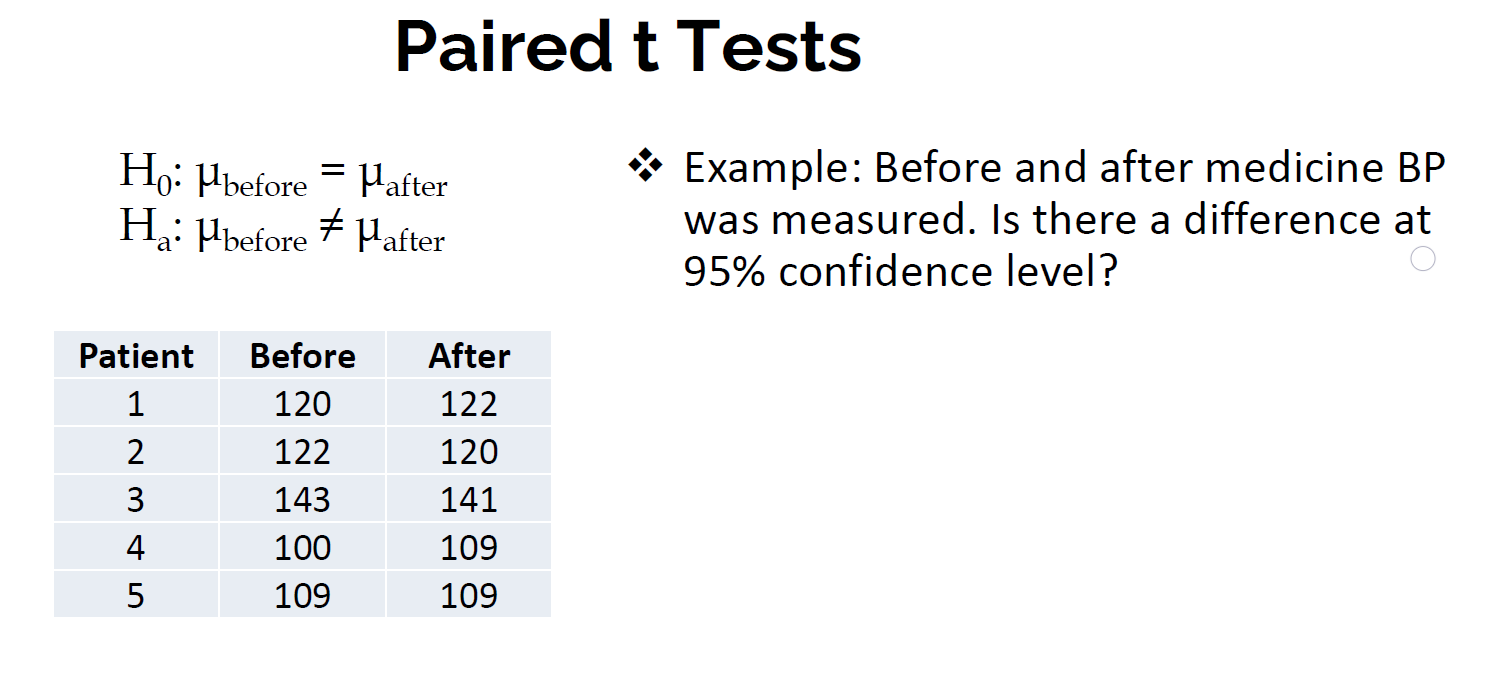

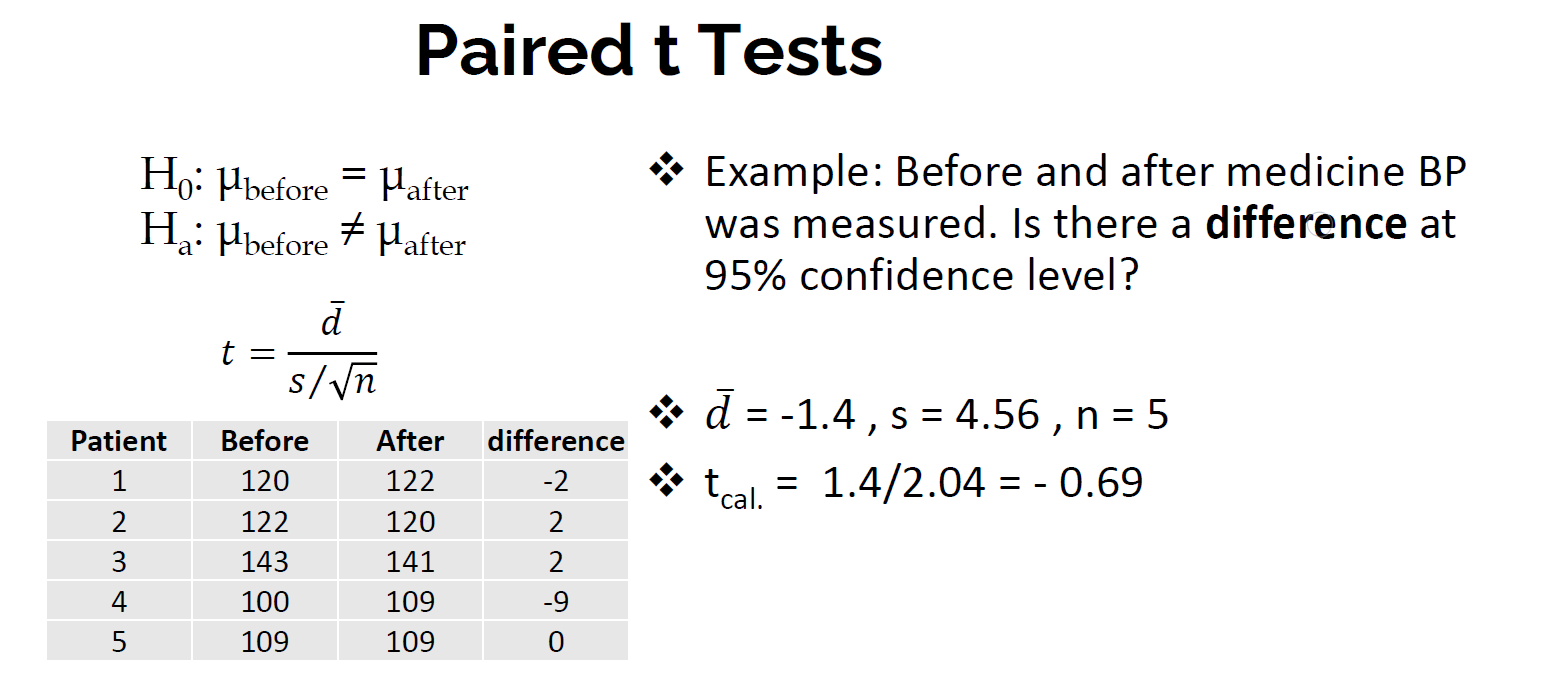

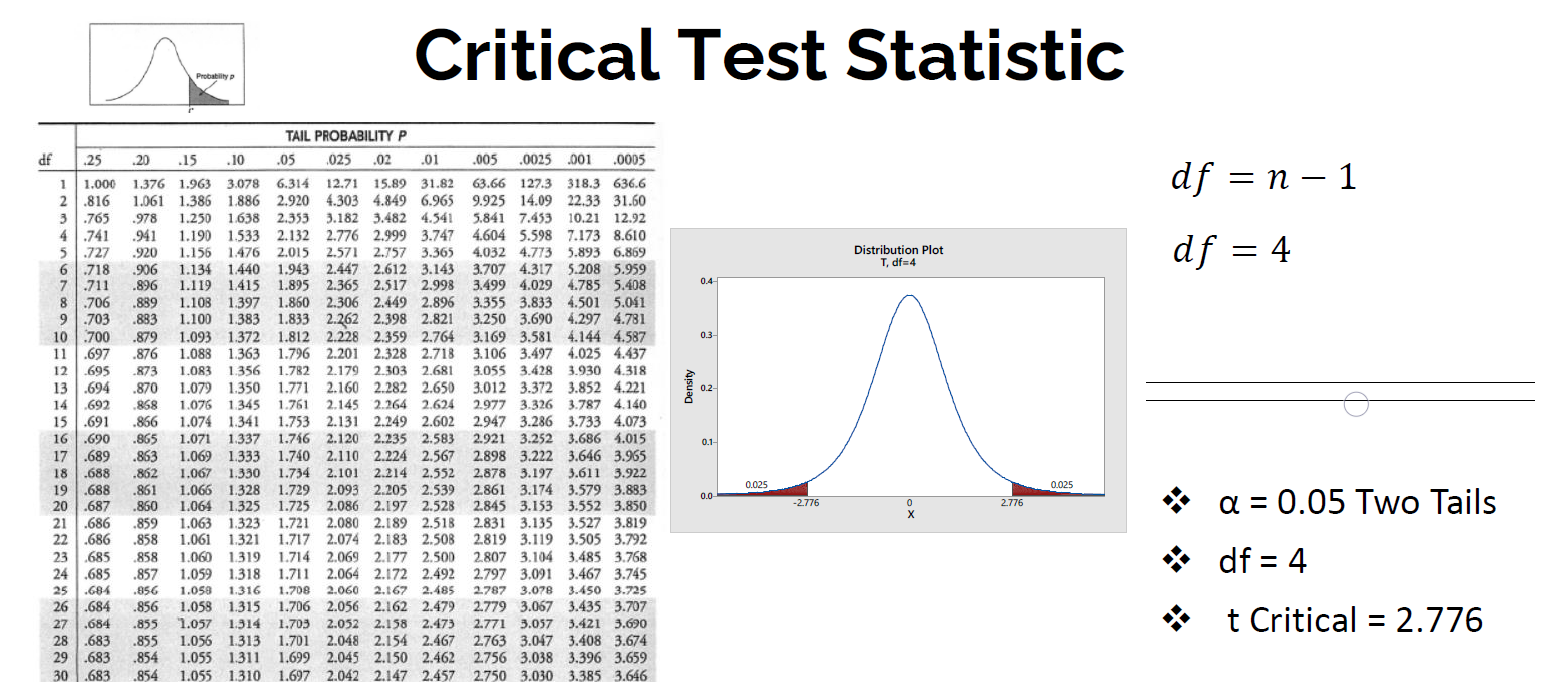

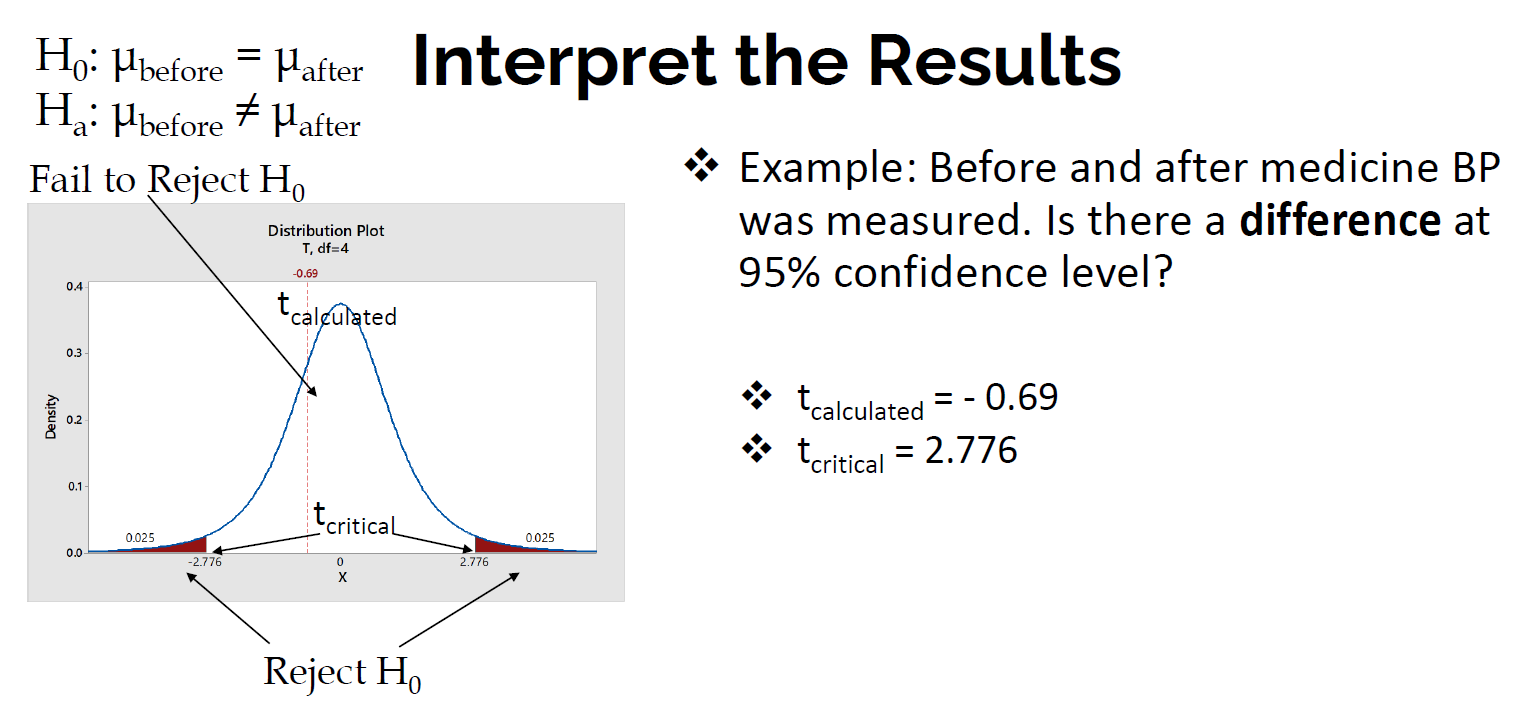

### Paired t Test Using Python:

Example: Before and after medicine BP was measured. Is there a difference at 95% confidence level?

H0 : μBefore = μAfter

Ha : μBefore != μAfter

alpha = 0.05

In [44]:
before_bp = [120, 122, 143, 100, 109]
after_bp = [122, 120, 141, 109, 109]

In [45]:
# Calculated Statistics:

t_calculated, p_value = ttest_rel(a= before_bp, b= after_bp, 
                                  alternative= 'two-sided')

In [46]:
print(t_calculated)
print(p_value)

-0.6864064729836442
0.5301776477578163


alpha = 0.05

p_value = 0.053 > alpha

**We Can Not Reject The Null Hypothesis.**

# ----------------------------------------------------------------------------------------------------------

## Two Proportions Test:

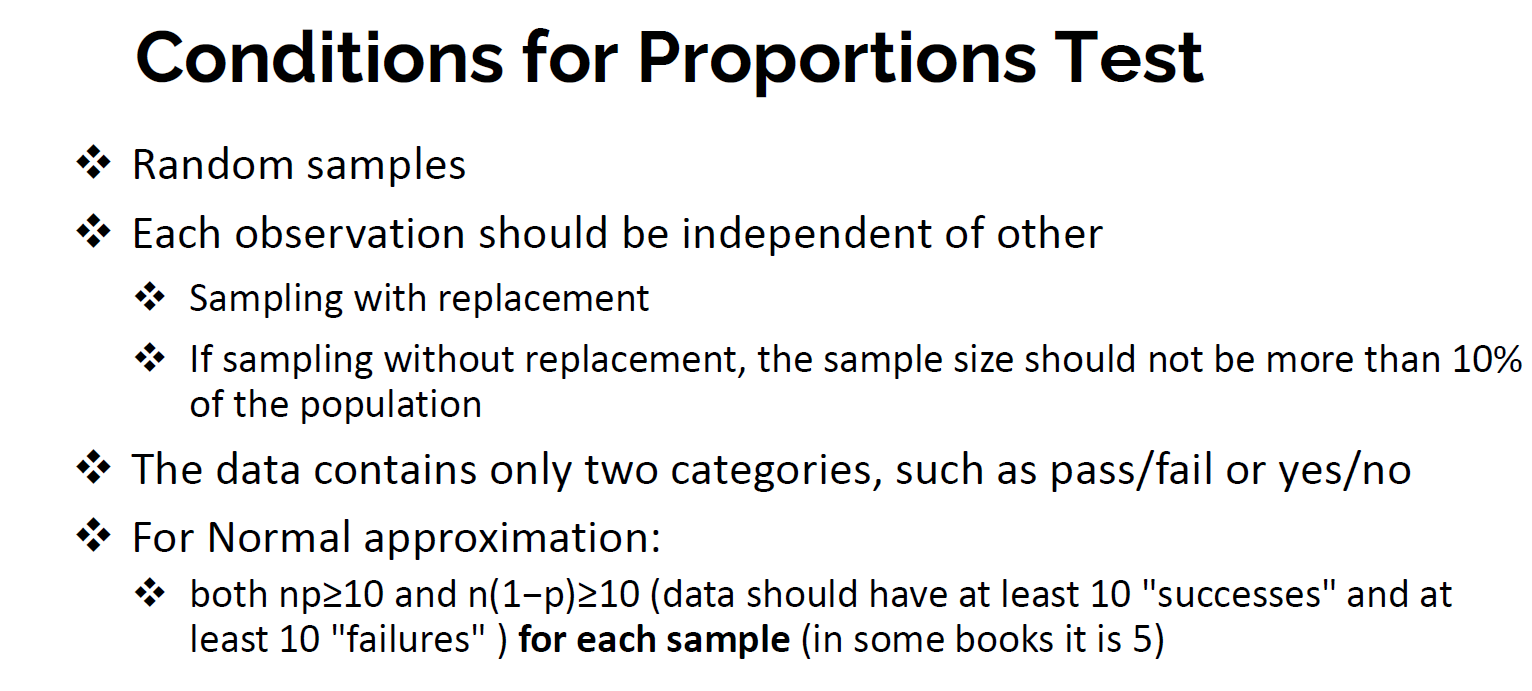

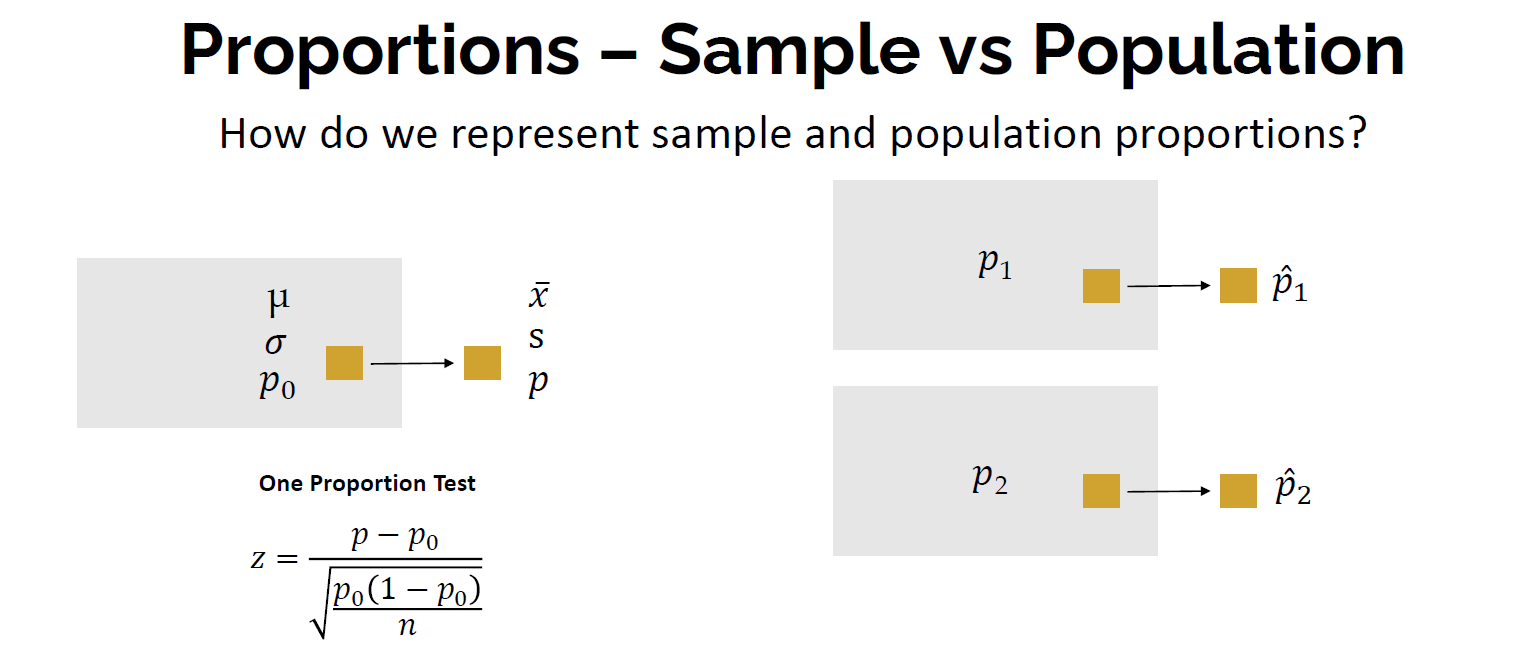

### Pooled Vs. Unpooled Method For Two Proportions Test:

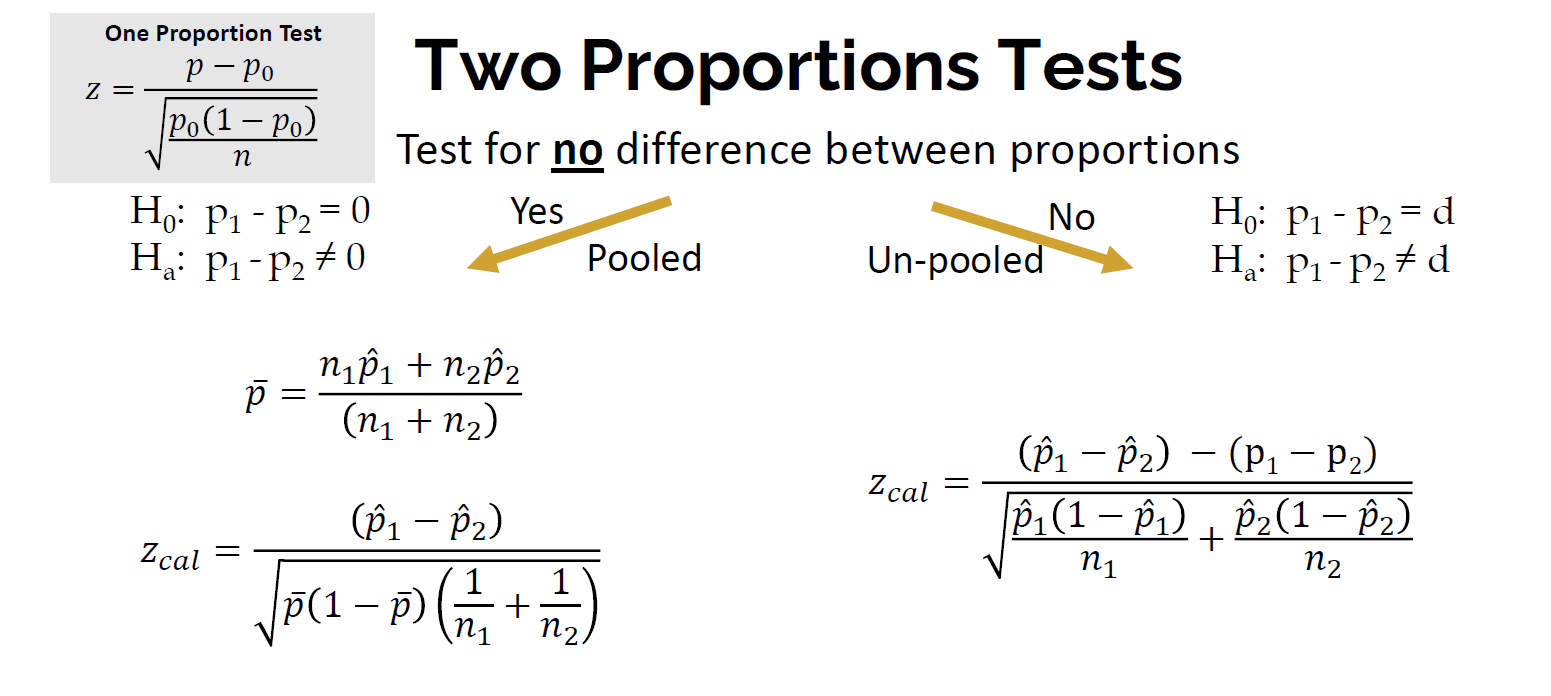

### Example (Pooled Method):

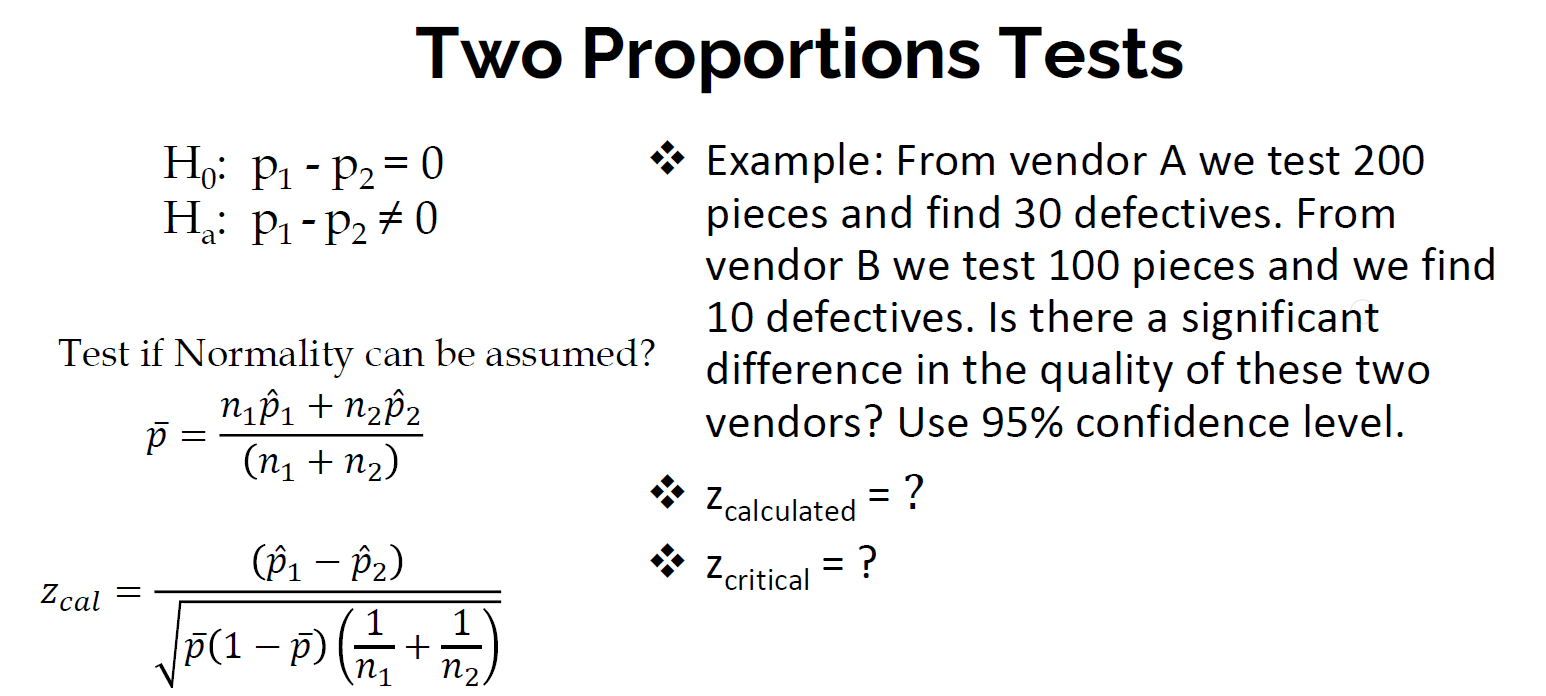

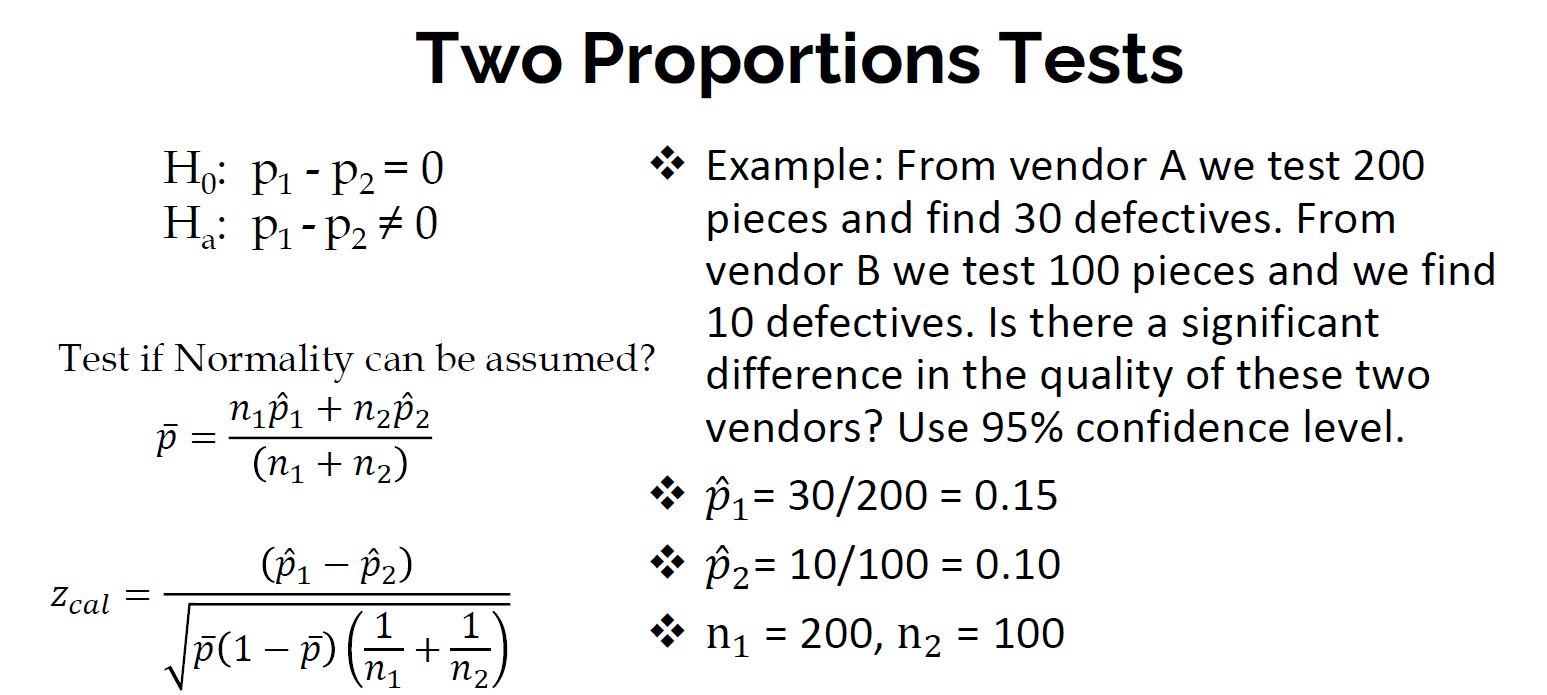

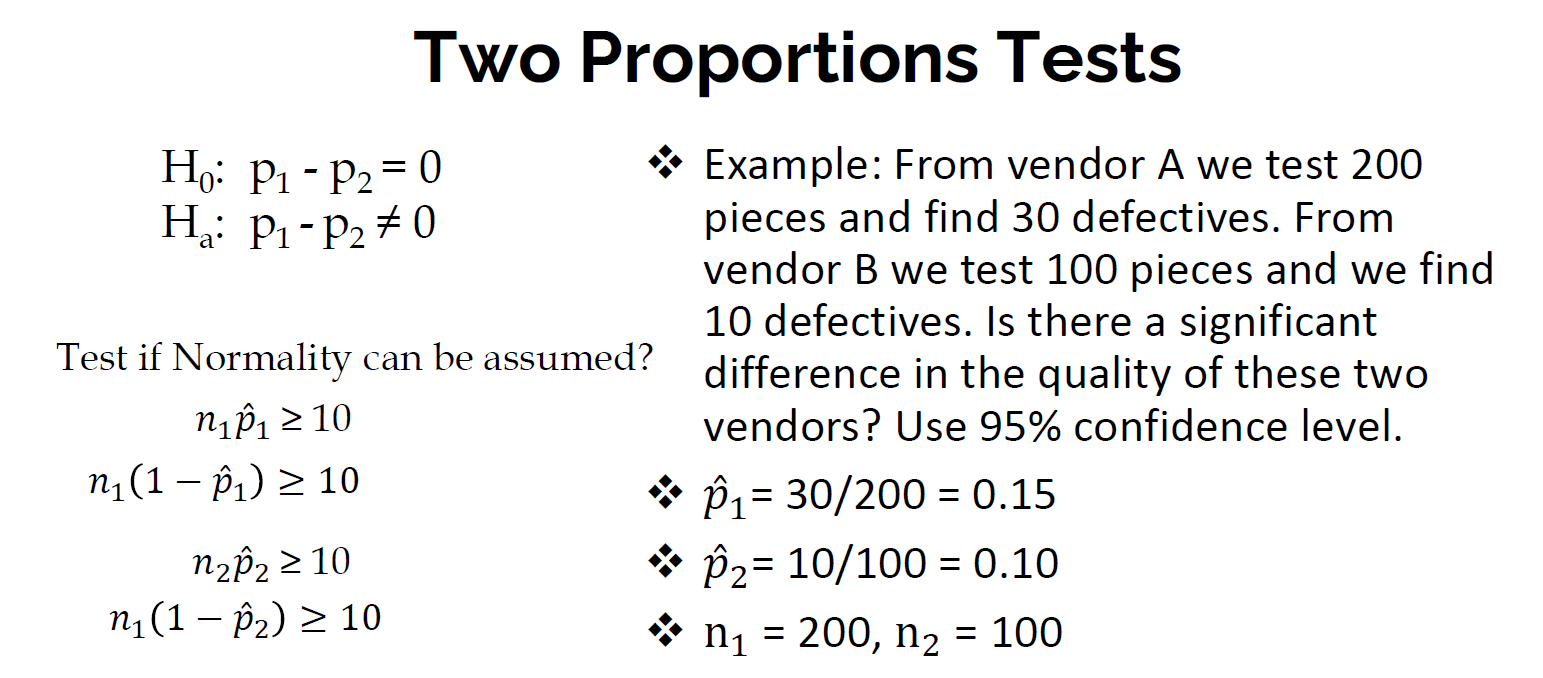

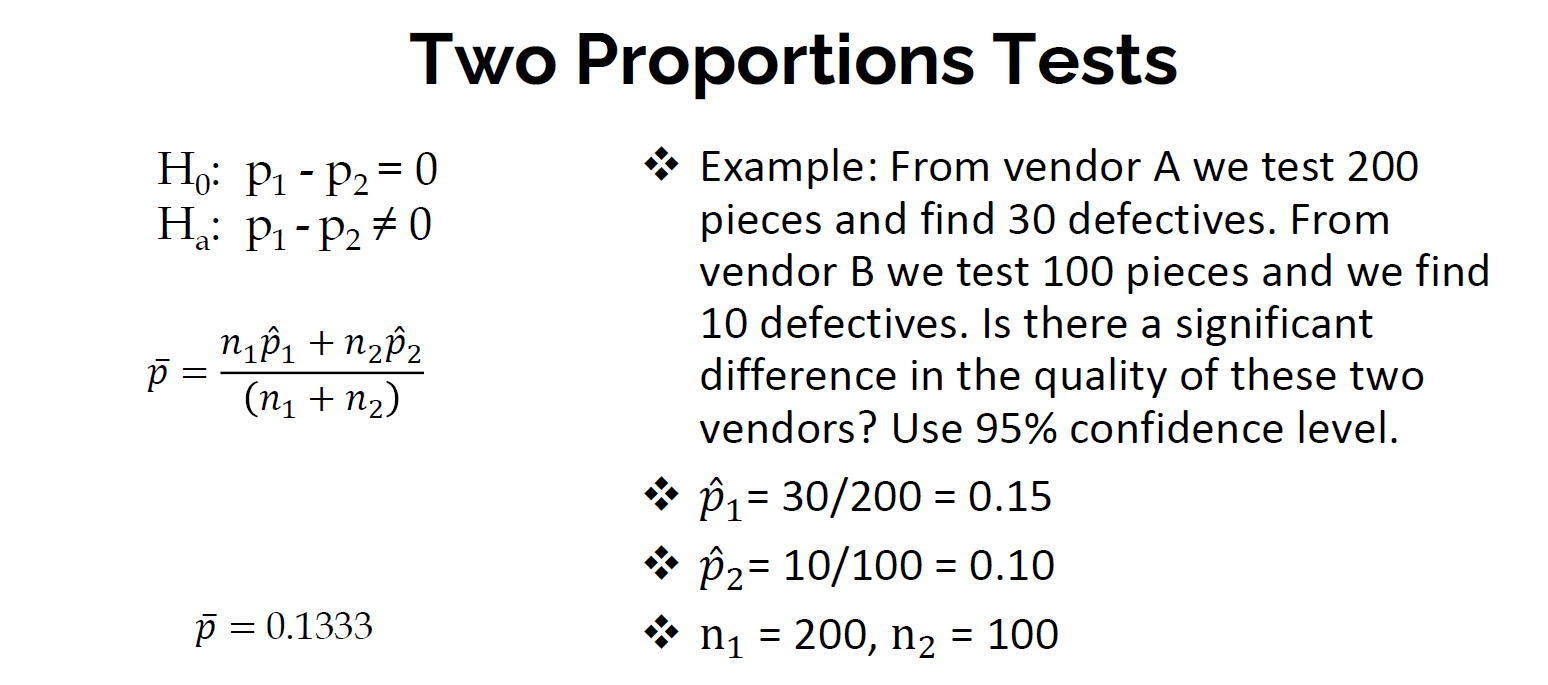

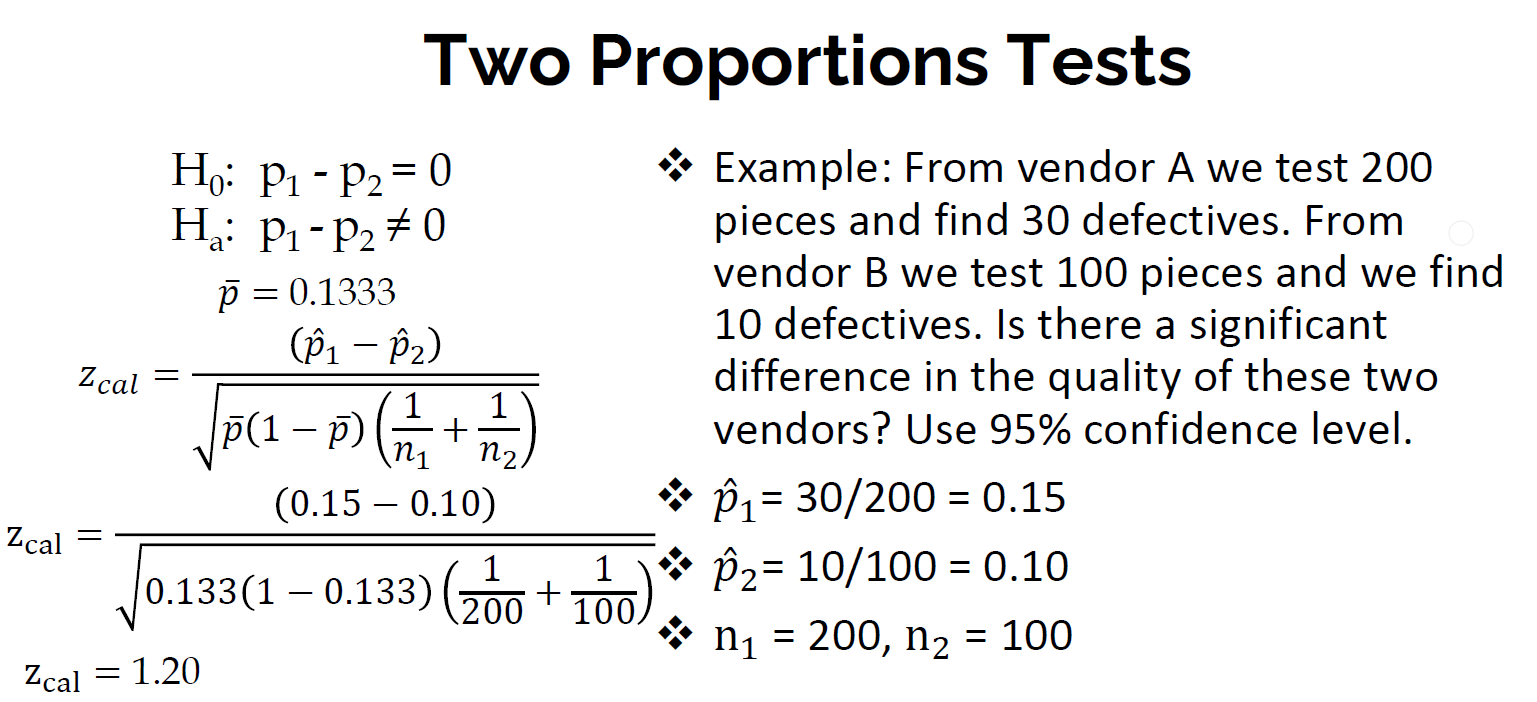

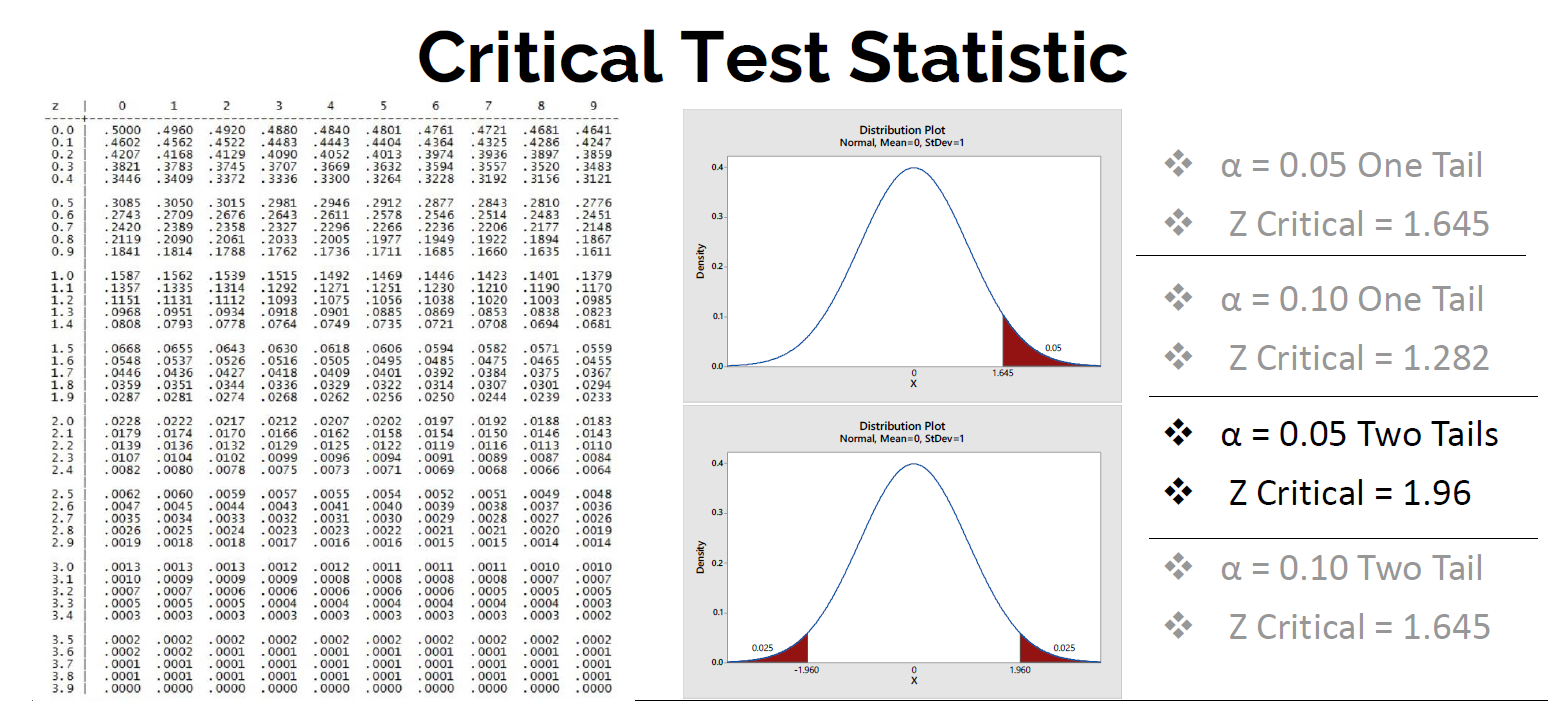

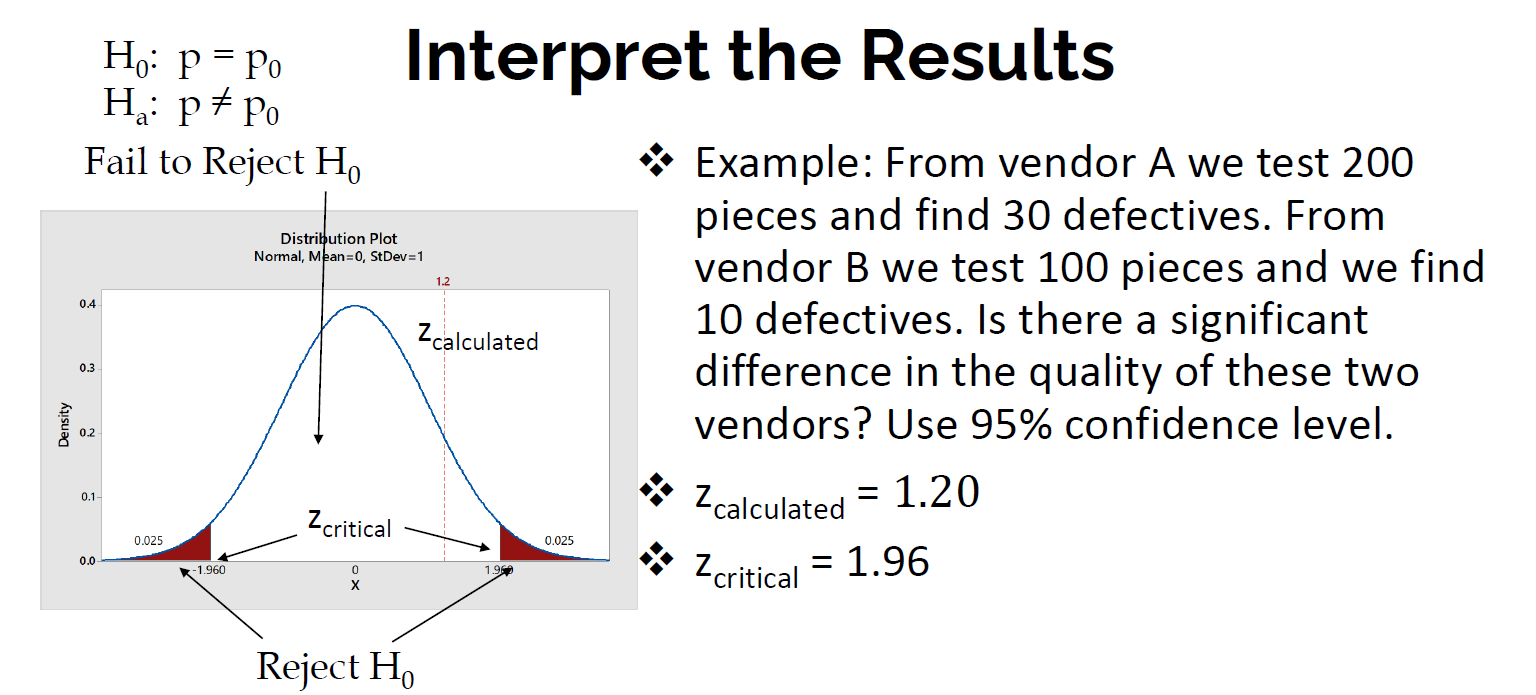

### Two Proportions Test Using Python:

##### Example: From vendor A we test 200 pieces and find 30 defectives. From vendor B we test 100 pieces and we find 10 defectives. Is there a significant difference in the quality of these two vendors? Use 95% confidence level.

H0 : pa = pb

Ha : pa != pb

alpha = 0.05

In [49]:
test_proportions_2indep(count1= 30, nobs1= 200, 
                        count2= 10, nobs2= 100, alternative= 'two-sided')

<class 'statsmodels.stats.base.HolderTuple'>
statistic = 1.145433008876846
pvalue = 0.2520298311822946
compare = 'diff'
method = 'agresti-caffo'
diff = 0.04999999999999999
ratio = 1.4999999999999998
odds_ratio = 1.588235294117647
variance = 0.001586401953652147
alternative = 'two-sided'
value = 0
tuple = (1.145433008876846, 0.2520298311822946)

alpha = 0.05

p-Value = 0.25 > alpha

**We can not reject Null Hypothesis.**

In [50]:
test_proportions_2indep(count1= 30, nobs1= 200, count2= 10, nobs2= 100, alternative= "two-sided", method= "score")

<class 'statsmodels.stats.base.HolderTuple'>
statistic = 1.1989578808281796
pvalue = 0.2305443235633593
compare = 'diff'
method = 'score'
variance = 0.001739130434782609
alternative = 'two-sided'
prop1_null = 0.13333333333333333
prop2_null = 0.13333333333333333
tuple = (1.1989578808281796, 0.2305443235633593)
diff = 0.04999999999999999
ratio = 1.4999999999999998
odds_ratio = 1.588235294117647
value = 0

alpha = 0.05

p-Value = 0.23 > alpha

**We can not reject Null Hypothesis.**

# ---------------------------------------------------------------------------------------------------------------

## Two Variances Test:

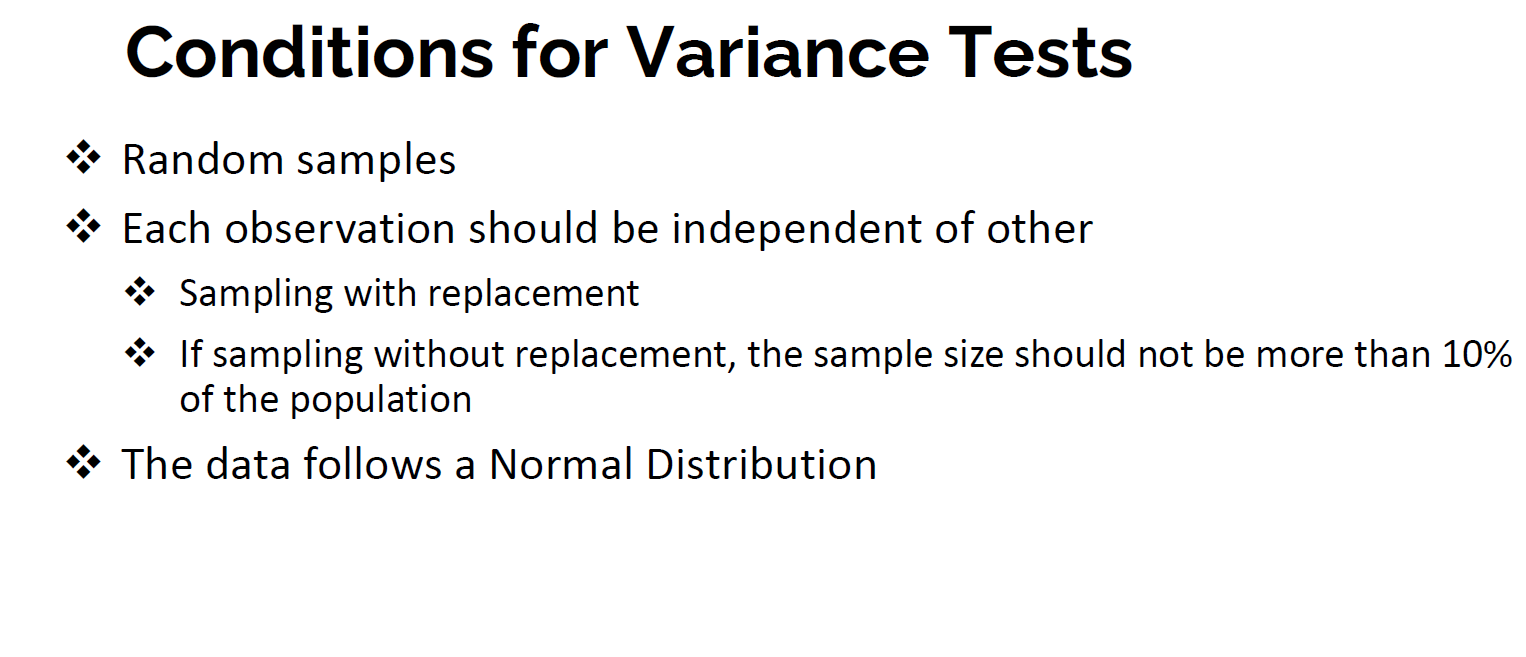

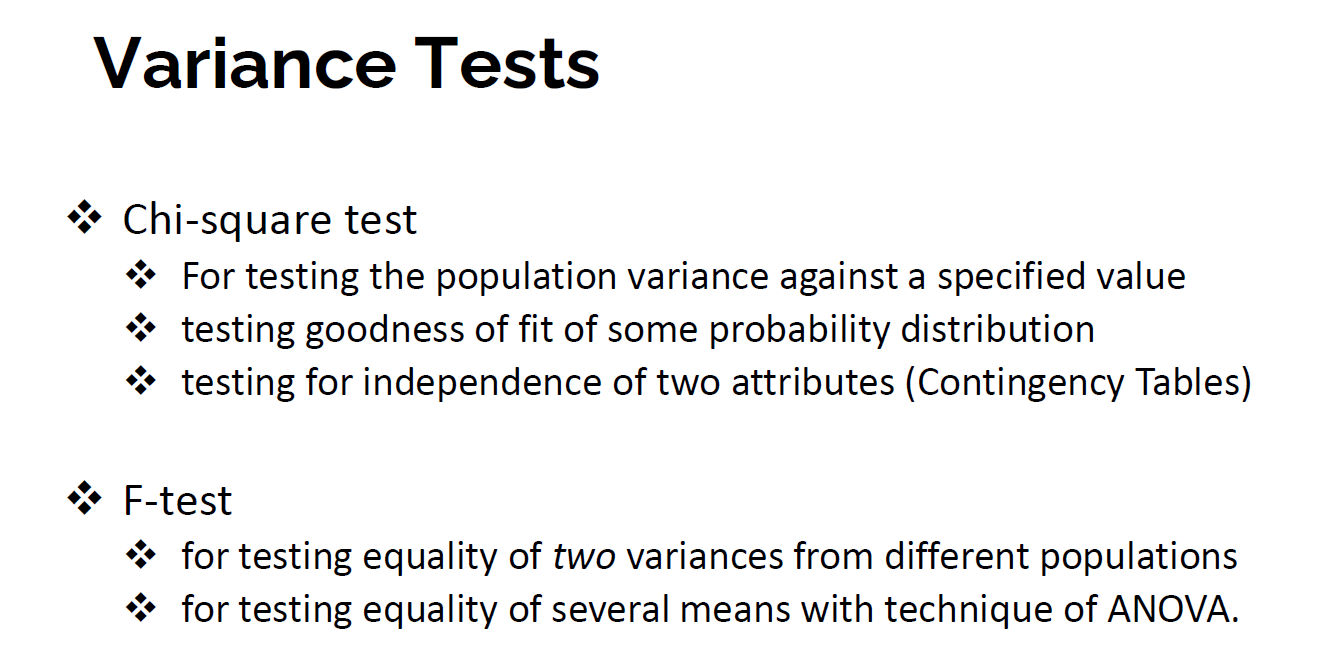

### Example:

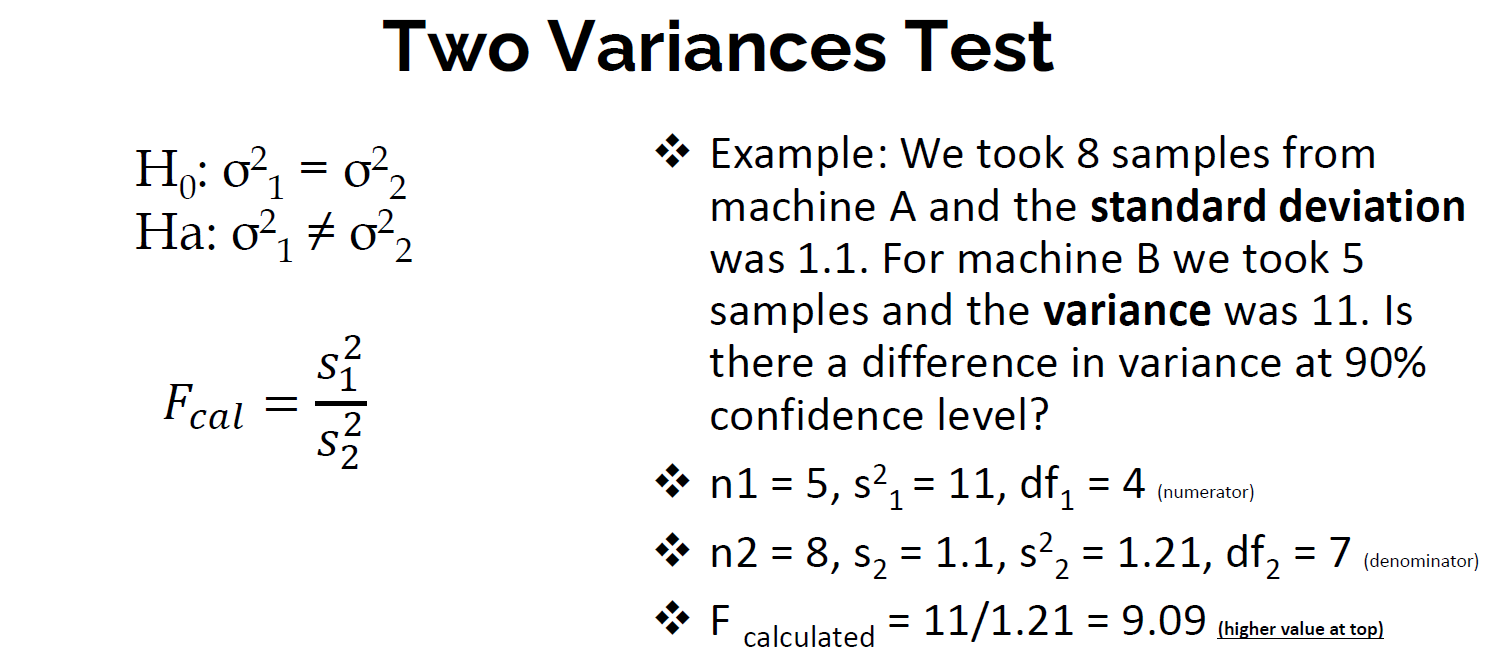

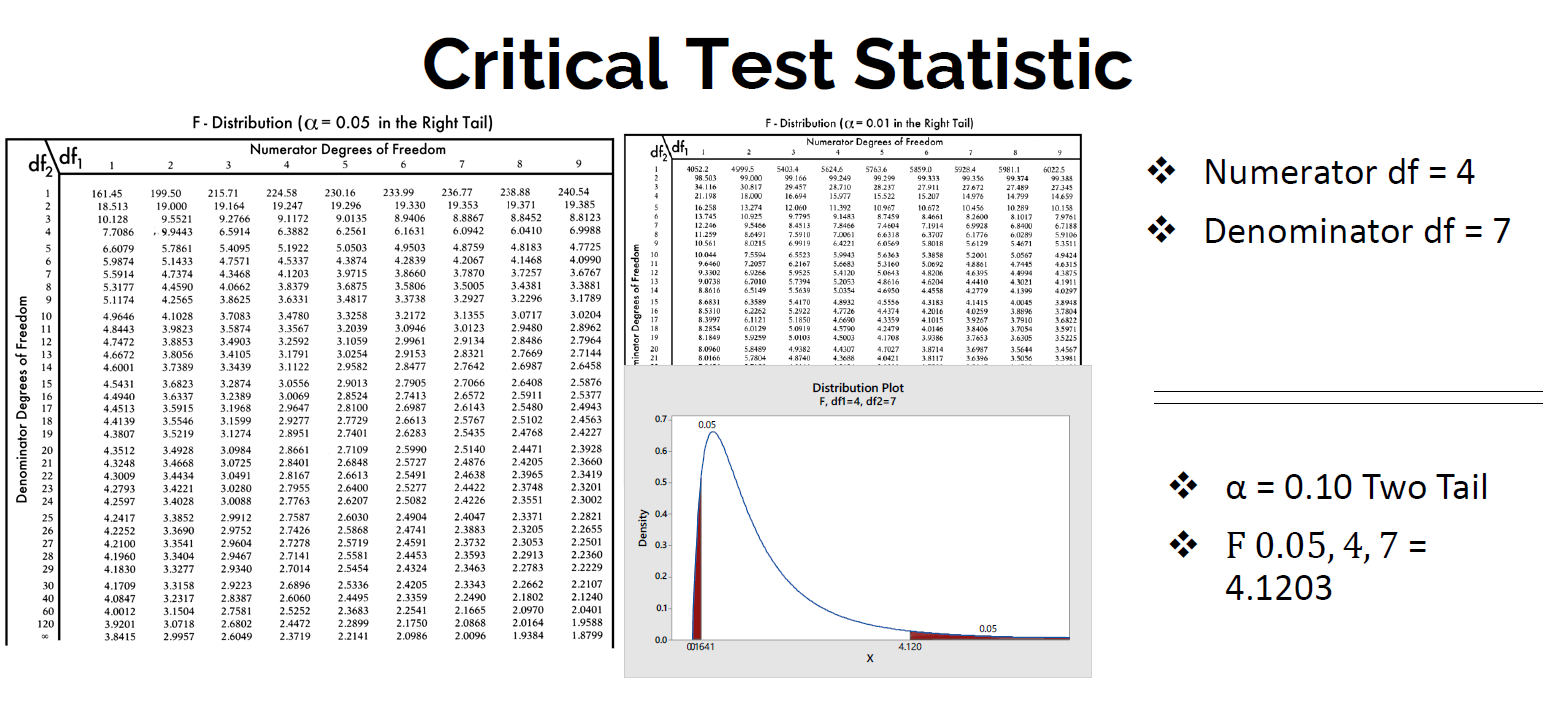

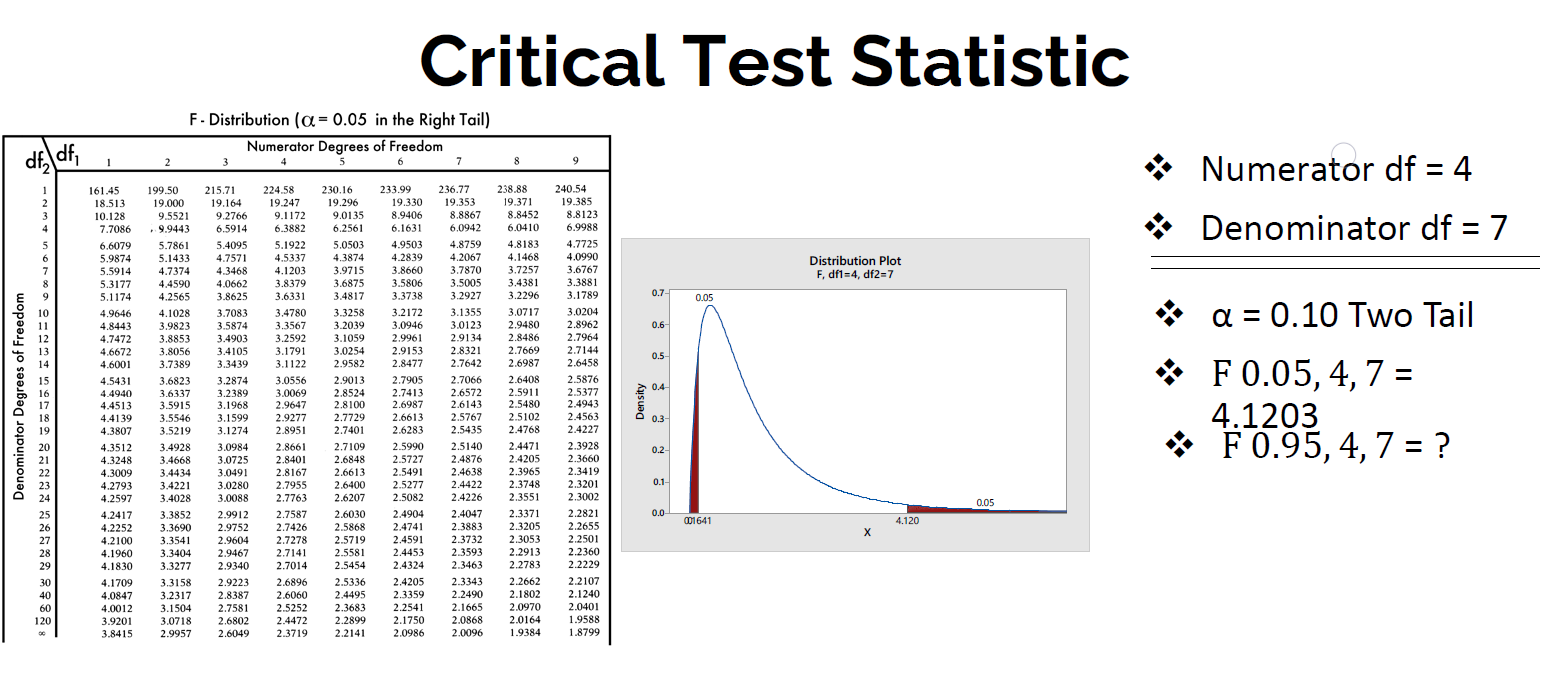

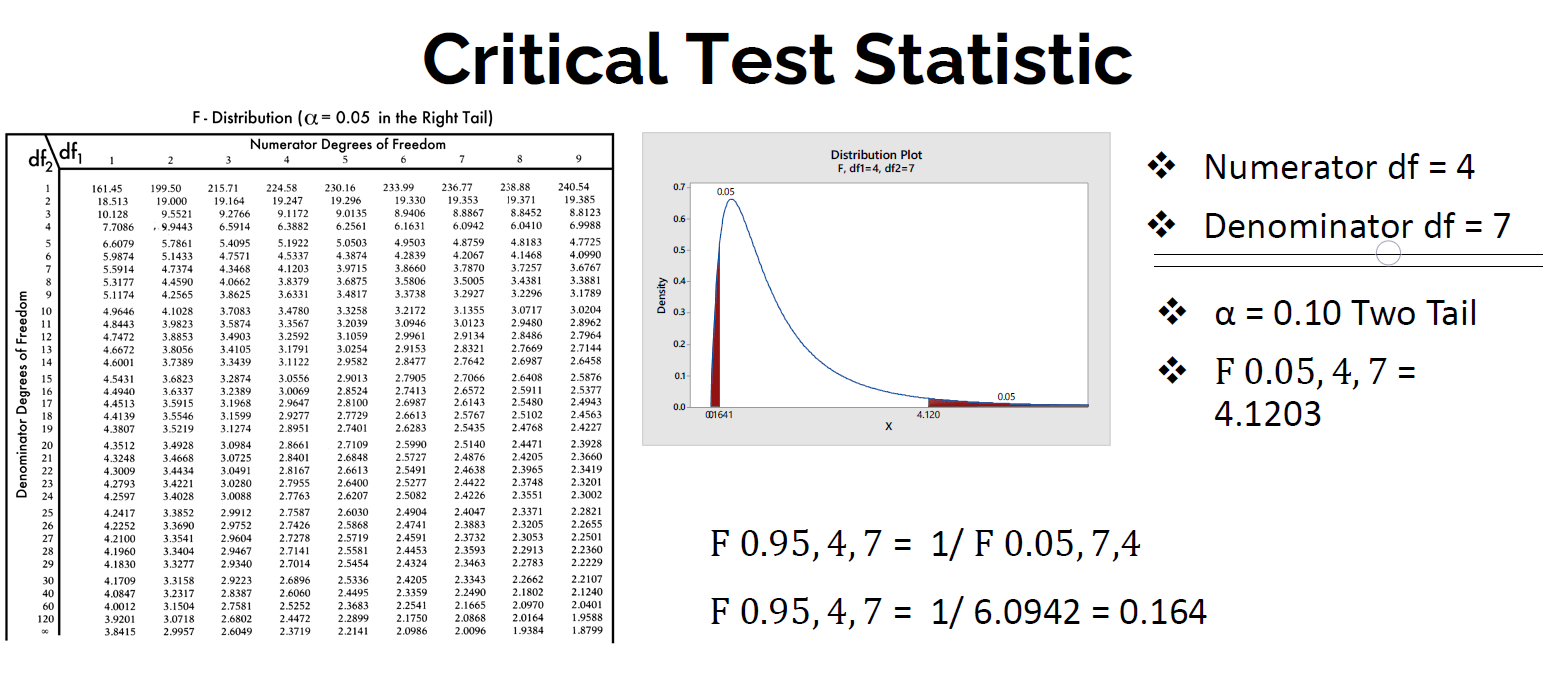

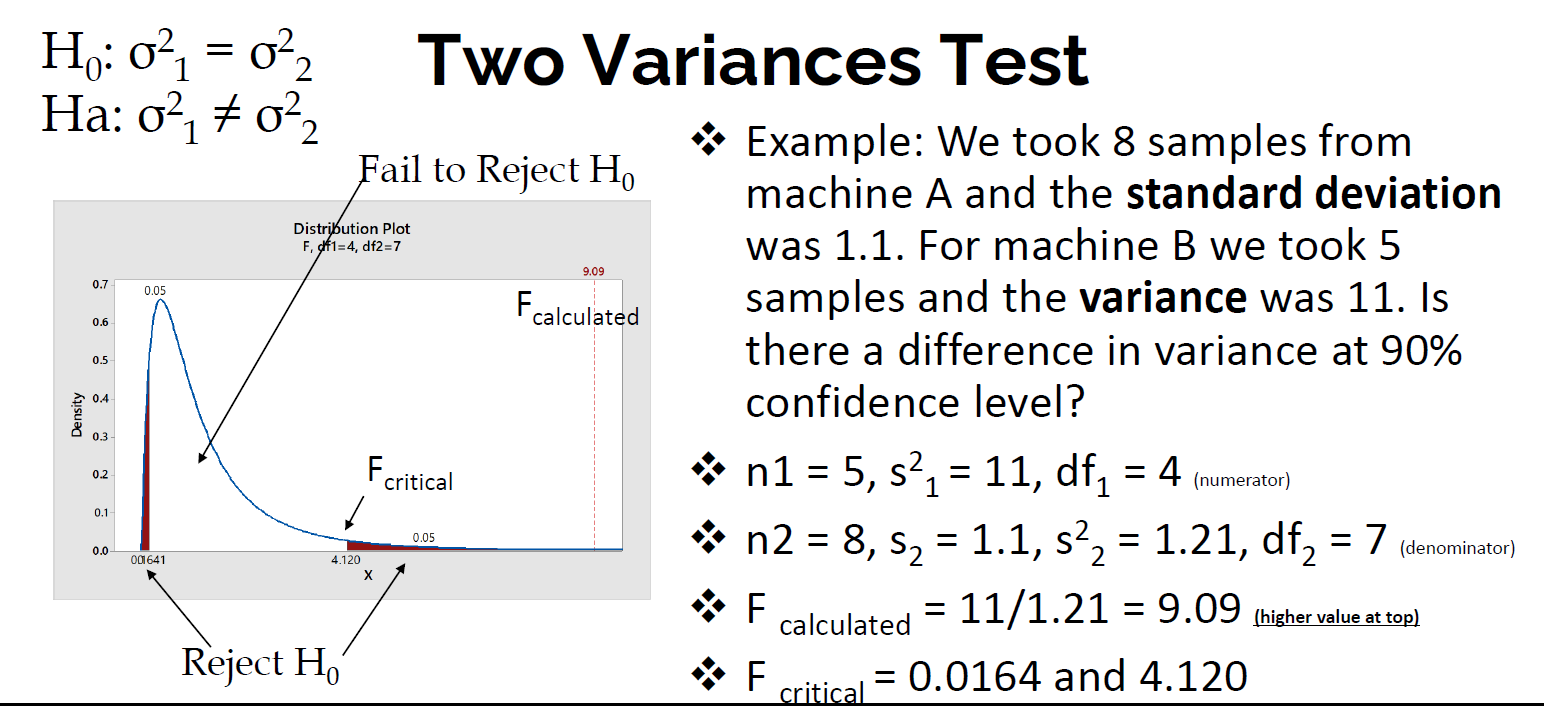

### Two Variances Test Using Python:

##### Example: We took 8 samples from machine A and the standard deviation was 1.1. For machine B we took 5 samples and the variance was 11. Is there a difference in variance at 90% confidence level?

H0 : σ2 1 = σ2 2

Ha : σ2 1 != σ2 2

alpha = 0.1

n1 = 5, s2 1 = 11, df1 = 4 (Numerator)

n2 = 8, s2 = 1.1, s2 2 = 1.21, df2 = 7 (Denominatior)

𝐹_𝑐𝑎𝑙=𝑠2 1 / 𝑠2 2

In [52]:
f_calculated = 11 / 1.21

In [53]:
f_calculated

9.090909090909092

In [54]:
f_critical_right_tail = f.isf(q= 0.05, dfn = 4, dfd= 7)

In [55]:
f_critical_right_tail

4.120311726897633

In [56]:
f_critical_left_tail = f.isf(q= 0.95, dfn = 4, dfd = 7)

In [57]:
f_critical_left_tail

0.1640901524729093

f_calculted is not between f_critical_left_tail and f_critical_right_tail.

**We can Reject Null Hypothesis.**

### Bartlett Test:

In [58]:
machine_a = [150, 150, 151, 148, 151, 152, 149, 150]

In [59]:
np.std(machine_a)

1.165922381636102

In [61]:
machine_b = [135, 152, 154, 169, 157]

In [62]:
np.std(machine_b)

10.9288608738514

In [63]:
bartlett(machine_a, machine_b)

BartlettResult(statistic=19.105727631632714, pvalue=1.2367317910523616e-05)

alpha = 0.1

p_Value = 0.000012

p_Value < alpha

**We can Reject Null Hypothesis.**

### Levene Test:

In [64]:
levene(machine_a, machine_b)

LeveneResult(statistic=5.416245804750017, pvalue=0.040060452607943706)

alpha = 0.1

p_Value = 0.04 < alpha

**We can Reject Null Hypothesis.**